In [1]:
import sys
import os
# Add the parent directory of `notebook/` to sys.path
sys.path.append(os.path.abspath(".."))

import torch
palette = ['#43AA8B', '#F8961E', '#F94144']
sub = str.maketrans("0123456789", "₀₁₂₃₄₅₆₇₈₉")

# data pre-processing and visualization
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import interp1d

# utilities
from utils.utils_data import (load_data, format_chemical_formula)
from e3nn.io import CartesianTensor

bar_format = '{l_bar}{bar:10}{r_bar}{bar:-10b}'
default_dtype = torch.float64
torch.set_default_dtype(default_dtype)

# Create a colormap based on the number of unique symbols
datasets = ['g', 'y', 'r']
colors = dict(zip(datasets, palette))
cmap = mpl.colors.LinearSegmentedColormap.from_list('cmap', [palette[k] for k in [0,2,1]])
mpl.rcParams['font.family'] = 'Arial'
font_size = 20  # or whatever size you want globally

mpl.rcParams.update({
    "font.size": font_size,           # Universal font size
    "axes.titlesize": font_size,       # Axes title
    "axes.labelsize": font_size,       # Axes labels
    "xtick.labelsize": font_size - 2,  # X tick labels
    "ytick.labelsize": font_size - 2,  # Y tick labels
    "legend.fontsize": font_size - 2,  # Legend text
    "figure.titlesize": font_size + 2, # Figure title
    "font.family": "Arial"             # Optional: use Arial everywhere
})

# Check device
device = "cuda:0" if torch.cuda.is_available() else "cpu"
print('torch device:' , device)

## load data
data_file1 = '../dataset/symmetrized_dataset_with_bandgap.pkl'
df, species = load_data(data_file1)
df = df.reset_index(drop=True)

print('data acquired')
df.head()

torch device: cuda:0
data acquired


,formula,symmetrized_structure,mp_id,bandgap_openmx,bandgap_mp,bandgap_type,crystal_system,omega,species,real_symmetrized_susceptibility,imag_symmetrized_susceptibility,rotation_matrices,rel_permittivity_real,rel_permittivity_imag,optical_bandgap,omega_p_loss
0,Li4Se8Y4,"(Atom('Li', [2.8385500000000006, 0.0, 2.88335]...",mp-37879,1.399564,1.6604,Direct,tetragonal,"[0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07...","[Y, Li, Se]","[[[3.4812758467294405, 0.0, -2.584939414228211...","[[[-1.2523566768095863e-17, 0.0, -4.8148248609...","[[[1.0, 0.0, 0.0], [0.0, 1.0, 0.0], [0.0, 0.0,...","[[[4.4812758467294405, 0.0, -2.584939414228211...","[[[-1.2523566768095863e-17, 0.0, -4.8148248609...",2.432209,12.63
1,Mo3S2Se4,"(Atom('Mo', [1.6365999999999998, 0.94489145055...",mp-1025906,0.654262,0.5619,Direct,trigonal,"[0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07...","[S, Mo, Se]","[[[5.124538605076387, 6.794333614242494e-18, 5...","[[[2.6245939830145304e-17, -2.5679065925163146...","[[[1.0, 3.969365967485894e-18, 0.0], [0.0, 1.0...","[[[6.124538605076387, 6.794333614242494e-18, 5...","[[[2.6245939830145304e-17, -2.5679065925163146...",2.176982,15.65
2,Li3NbS4,"(Atom('Li', [0.0, 0.0, 3.0251], index=0), Atom...",mp-755309,2.968668,2.8348,Indirect,cubic,"[0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07...","[Nb, Li, S]","[[[1.7313150452437125, -3.529303946892918e-23,...","[[[9.73175816465002e-19, 0.0, 0.0], [0.0, 9.73...","[[[1.0, 0.0, 0.0], [0.0, 1.0, 0.0], [0.0, 0.0,...","[[[2.7313150452437123, -3.529303946892918e-23,...","[[[9.73175816465002e-19, 0.0, 0.0], [0.0, 9.73...",3.072585,12.47
3,CdSe2Zn,"(Atom('Zn', [2.07525, 2.07525, 2.981], index=0...",mp-1017534,0.940717,0.7236,Direct,tetragonal,"[0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07...","[Cd, Zn, Se]","[[[3.2667200732203123, 0.0, 0.0], [0.0, 3.2667...","[[[-8.841535879698145e-18, 0.0, -9.62964972193...","[[[1.0, 0.0, 0.0], [0.0, 1.0, 0.0], [0.0, 0.0,...","[[[4.266720073220313, 0.0, 0.0], [0.0, 4.26672...","[[[-8.841535879698145e-18, 0.0, -9.62964972193...",1.134081,12.68
4,Al8Te12,"(Atom('Al', [-1.0110162555088607, 0.7063003620...",mp-1228524,1.460160,1.3222,Direct,monoclinic,"[0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07...","[Al, Te]","[[[3.57865600493003, 0.0, 0.0588499476841695],...","[[[-2.370171074423322e-18, 0.0, 3.360404376639...","[[[1.0, 0.0, 6.761473487721657e-17], [0.0, 1.0...","[[[4.57865600493003, 0.0, 0.0588499476841695],...","[[[-2.370171074423322e-18, 0.0, 3.360404376639...",3.719281,11.33


In [2]:
# data_file2 = '../dataset/symmetrized_dataset.pkl'
# df2, species2 = load_data(data_file2)
# df2 = df2.reset_index(drop=True)
# cols_to_drop = [col for col in df2.columns 
#                 if col.startswith("Re_") 
#                 or col.startswith("Im_") 
#                 or col in [
#                     "real_Permittivity_Matrices",
#                     "imag_Permittivity_Matrices",
#                     "avg_re_trace",
#                     "avg_im_trace"
#                 ]]

# df2 = df2.drop(columns=cols_to_drop)
# df2 = df2.rename(columns={
#     "real_symmetrized_permittivity": "real_symmetrized_susceptibility"
# })

# # If you also have the imaginary part:
# df2 = df2.rename(columns={
#     "imag_symmetrized_permittivity": "imag_symmetrized_susceptibility"
# })
# print(f"Dropped {len(cols_to_drop)} columns")
# print('data acquired')
# df2.head()


In [3]:
# # Pick 5 common random indices
# common_indices = np.random.choice(df.index.intersection(df2.index), size=5, replace=False)

# for idx in common_indices:
#     arr1 = df['rel_permittivity_imag'].iloc[idx]  # shape (F, 3, 3)
#     arr2 = df2['rel_permittivity_imag'].iloc[idx]

#     plt.figure(figsize=(10, 6))
#     for i in range(3):
#         for j in range(i, 3):  # upper triangular only
#             diff = arr1[:, i, j] - arr2[:, i, j]
#             plt.plot(diff, label=f"({i},{j})")

#     plt.legend()
#     plt.xlabel("Frequency index")
#     plt.ylabel("Difference")
#     plt.title(f"Difference at common row {idx}")
#     plt.grid(True)
#     plt.show()

In [4]:
# import numpy as np
# import pandas as pd

# def add_identity_energy_dim(tensor):
#     """
#     Add 1 to the diagonal of each 3x3 matrix across the energy dimension.
#     Input tensor shape: (N_energy, 3, 3)
#     """
#     tensor = np.array(tensor)
#     assert tensor.ndim == 3 and tensor.shape[1:] == (3, 3), "Expected shape (N_energy, 3, 3)"
    
#     # Create identity matrices broadcasted over energy dimension
#     identity = np.eye(3)[np.newaxis, :, :]  # shape (1, 3, 3)
#     return tensor + identity  # shape (N_energy, 3, 3)

# # Apply to your DataFrame
# df["rel_permittivity_real"] = df["real_symmetrized_susceptibility"].apply(add_identity_energy_dim)
# df["rel_permittivity_imag"] = df["imag_symmetrized_susceptibility"]
# df = df.rename(columns={
#     "real_symmetrized_permittivity": "real_symmetrized_susceptibility",
#     "imag_symmetrized_permittivity": "imag_symmetrized_susceptibility"
# })
# # df2["rel_permittivity_real"] = df2["real_symmetrized_susceptibility"].apply(add_identity_energy_dim)
# # df2["rel_permittivity_imag"] = df2["imag_symmetrized_susceptibility"]
# # df2 = df2.rename(columns={
# #     "real_symmetrized_permittivity": "real_symmetrized_susceptibility",
# #     "imag_symmetrized_permittivity": "imag_symmetrized_susceptibility"
# # })
# df.to_pickle(data_file1)


In [5]:
from e3nn.o3 import wigner_D, Irrep
from e3nn.io import CartesianTensor

import torch
T = torch.tensor([
    [1.0, 0.0, 0.7],
    [0.0, 0.9, 0.0],
    [0.7, 0.0, 0.8],
])  # shape (3, 3)
perm = torch.tensor([1, 2, 0])
# Step 2: Make sure it’s symmetric

T_perm = T.index_select(0, perm).index_select(1, perm)

x = CartesianTensor("ij=ji")

sph_perm = x.from_cartesian(T_perm)
sph = x.from_cartesian(T)
print(sph_perm)
print(sph)


tensor([ 1.5588,  0.0000,  0.0000, -0.1225,  0.9899,  0.0707])
tensor([ 1.5588e+00,  9.8995e-01,  0.0000e+00,  1.1102e-16,  0.0000e+00,
        -1.4142e-01])


In [6]:
from e3nn.o3 import wigner_D, Irrep
from e3nn.io import CartesianTensor

import torch
T = torch.tensor([
    [1.0, 0.3, 0.7],
    [0.3, 0.9, 0.5],
    [0.7, 0.5, 0.8],
])  # shape (3, 3)
perm = torch.tensor([1, 2, 0])
# Step 2: Make sure it’s symmetric

T_perm = T.index_select(0, perm).index_select(1, perm)

x = CartesianTensor("ij=ji")

sph_perm = x.from_cartesian(T_perm)
sph = x.from_cartesian(T)
print(sph_perm)
print(sph)


tensor([ 1.5588,  0.4243,  0.7071, -0.1225,  0.9899,  0.0707])
tensor([ 1.5588e+00,  9.8995e-01,  4.2426e-01,  1.1102e-16,  7.0711e-01,
        -1.4142e-01])


# ORIGINAL METHOD

(1432, 3001, 6)
9.735763498218512


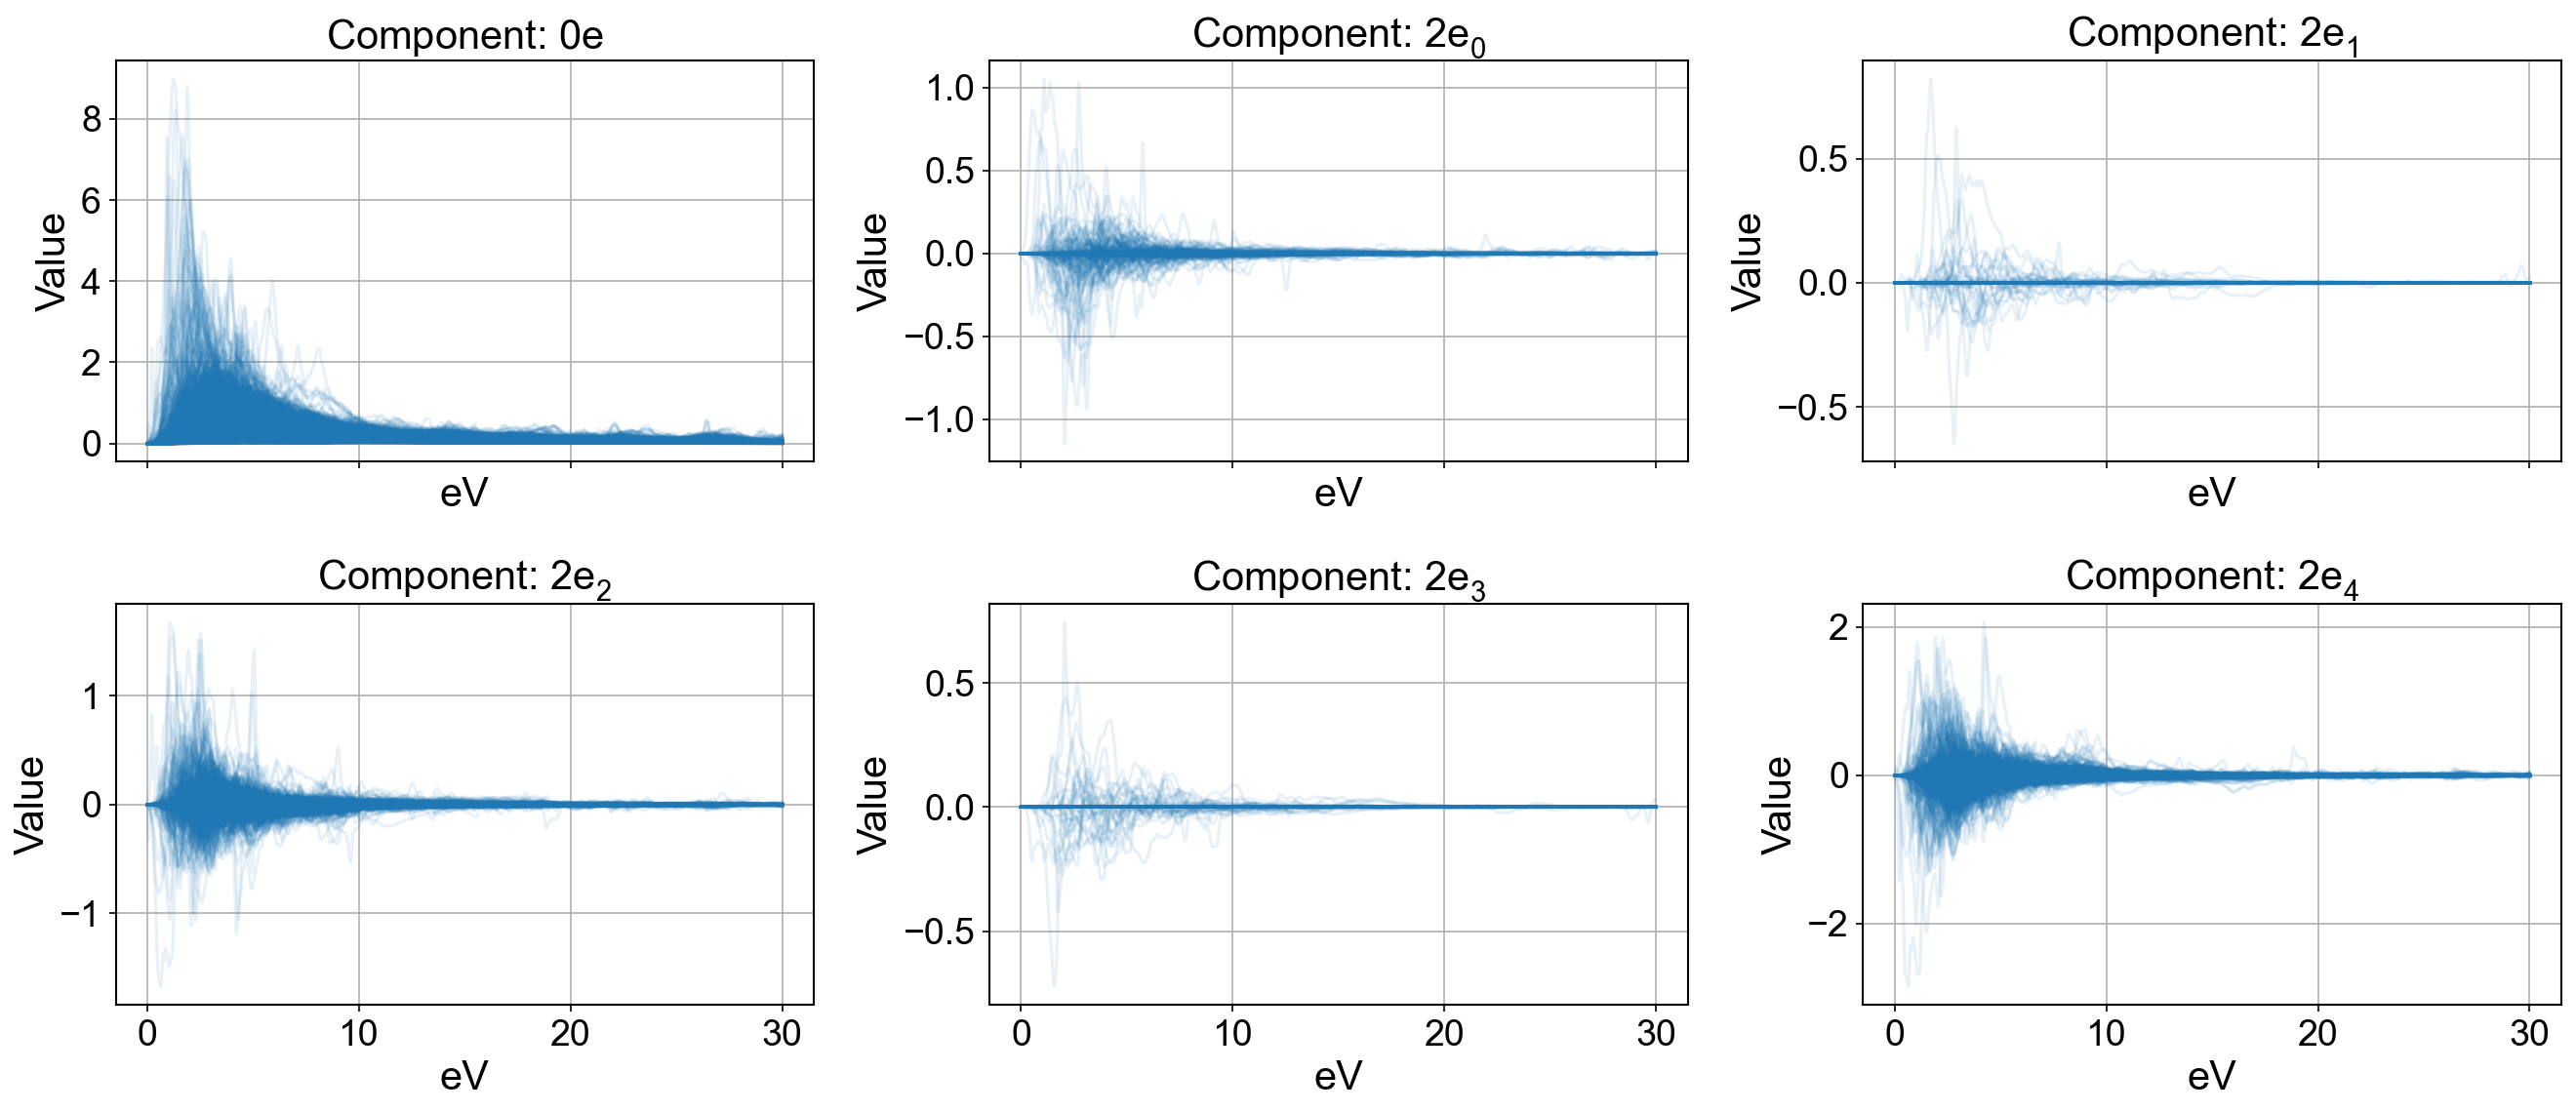

In [7]:
stack_matrices_tensor = torch.tensor(np.stack(df['rel_permittivity_imag'].values), dtype=torch.float64, device=device)  # Shape: (num_samples, 301, 3, 3)

# Transform Cartesian tensor to irreps
x = CartesianTensor("ij=ji")  # Symmetric rank-2 tensor
sph_coefs_tensor = x.from_cartesian(stack_matrices_tensor)  # Shape: (num_samples, 301, 6)
df['sph_coefs'] = list(sph_coefs_tensor.cpu().numpy())  # Move to CPU and store as list

# Find the scaling value
tmp = np.array([df.iloc[i]['sph_coefs'] for i in range(len(df))])
print(tmp.shape)
scale_data = np.median(np.max(np.abs(tmp), axis=(1, 2)))
print(scale_data)

# Labels (optional)
channel_labels = ["0e", "2e_0", "2e_1", "2e_2", "2e_3", "2e_4"]

# Frequency axis
freqs = np.linspace(0, 30, 3001)  # replace with your actual energy or omega grid
# Plotting
fig, axes = plt.subplots(2, 3, figsize=(18, 8), dpi=150, sharex=True)
axes = axes.flatten()

for i in range(6):
    ax = axes[i]
    ax.plot(freqs, sph_coefs_tensor[:, :, i].T.cpu().numpy()/scale_data, alpha=0.1, color='C0')  # each sample = one line
    ax.set_title(rf"Component: ${channel_labels[i]}$")
    ax.set_xlabel("eV")
    ax.set_ylabel("Value")
    ax.grid(True)

plt.tight_layout()
plt.show()



# NEW NORM METHOD

tensor(12.1746, device='cuda:0') tensor(2.4969, device='cuda:0')


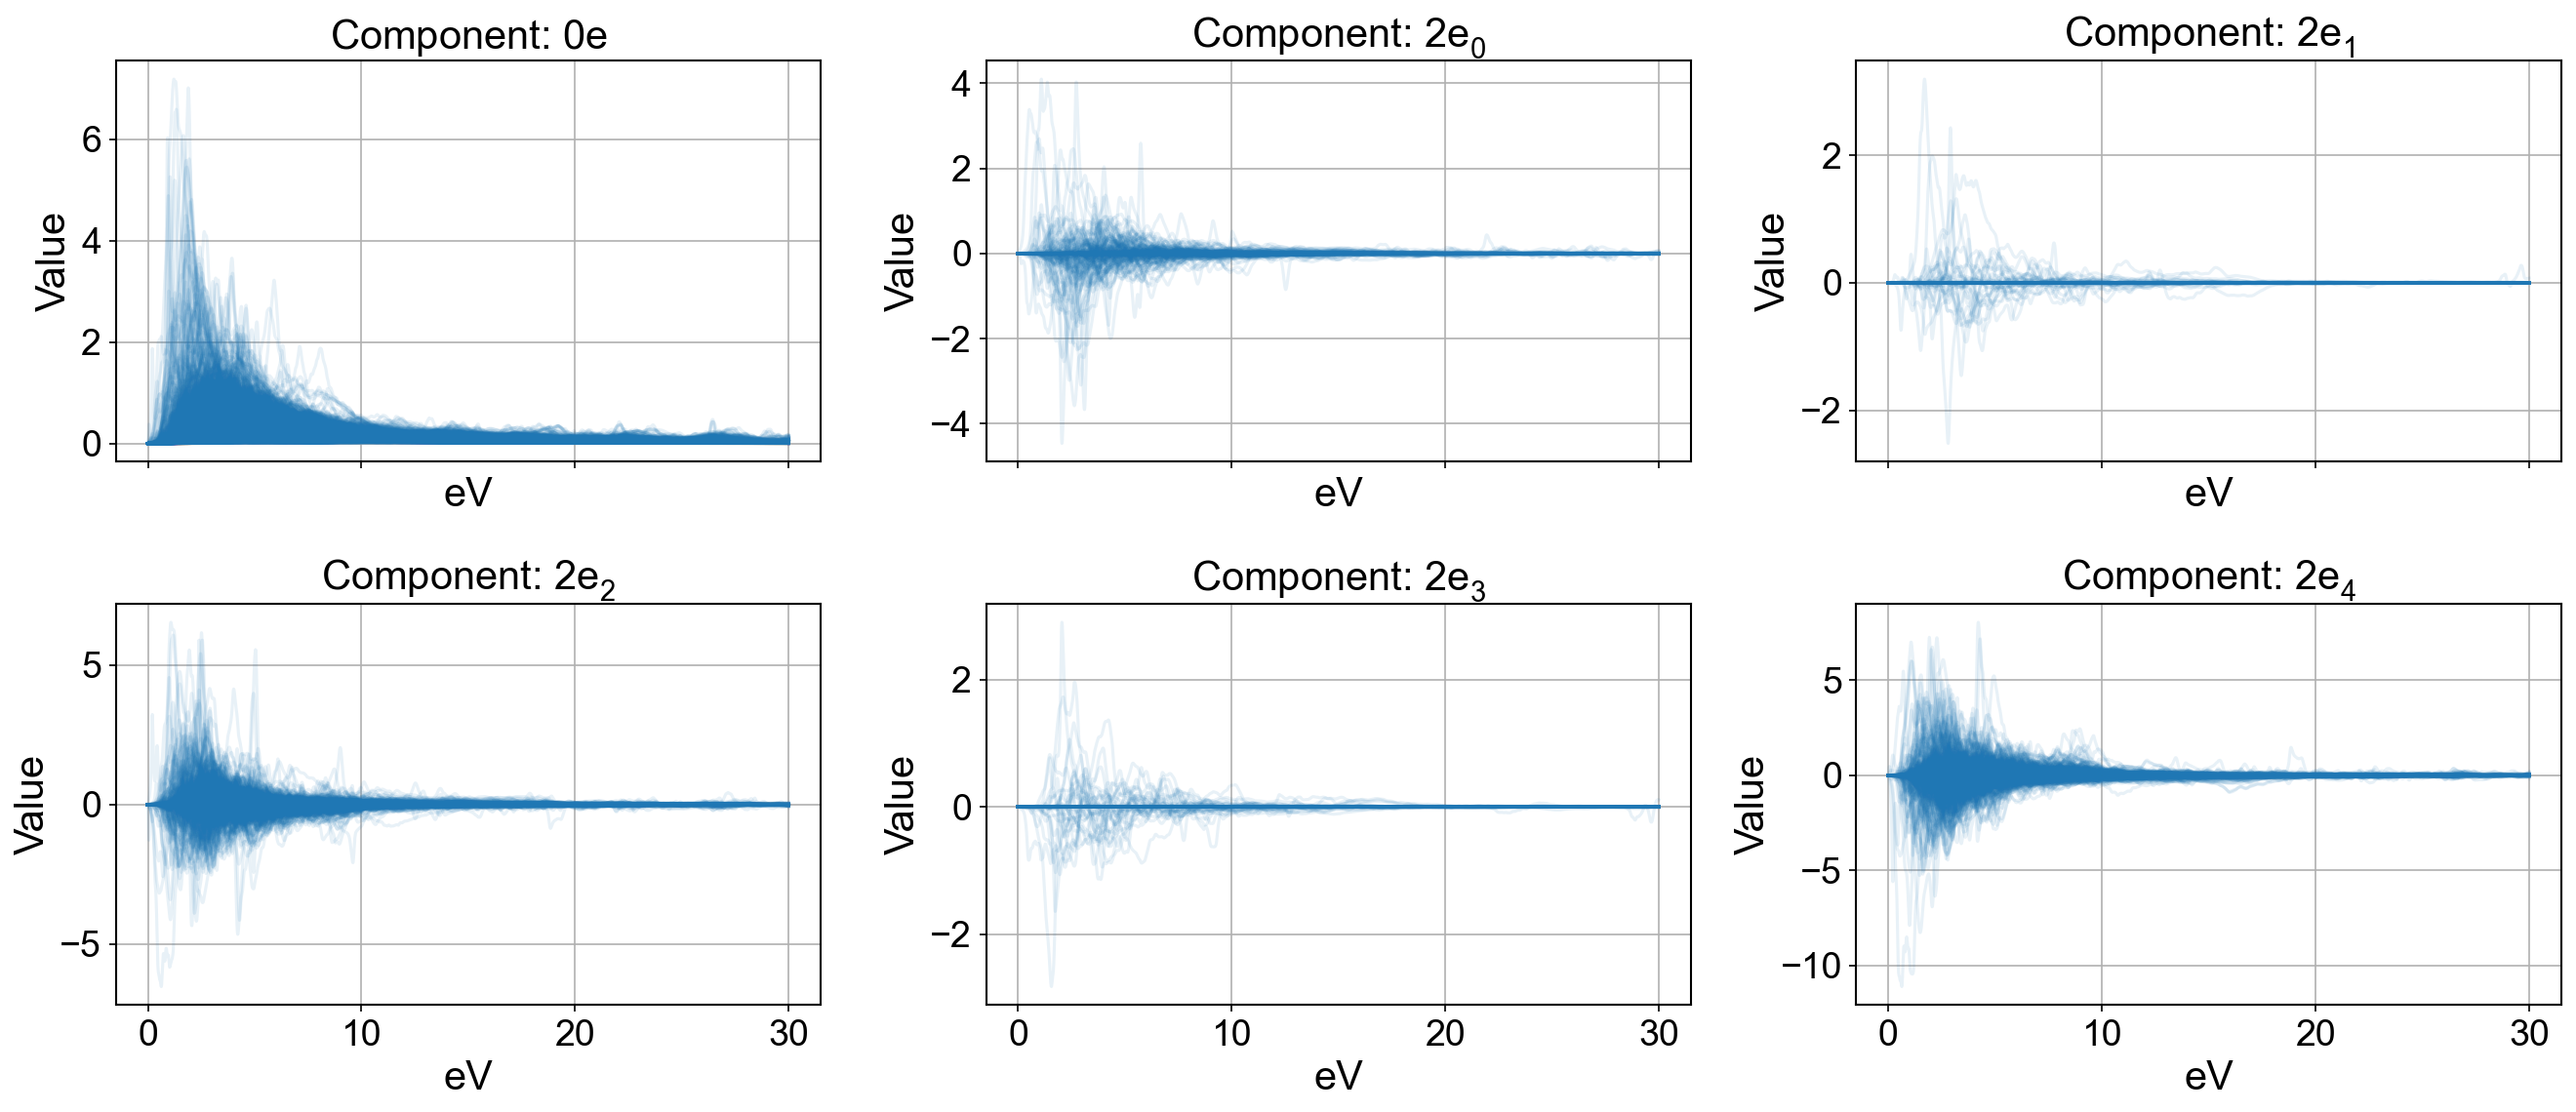

In [8]:
# Transform Cartesian tensor to irreps
stack_matrices_tensor = torch.tensor(np.stack(df['rel_permittivity_imag'].values), dtype=torch.float64, device=device)  # Shape: (num_samples, 301, 3, 3)
# Convert Cartesian to irreps (0e + 2e) with shape (N, F, 6)
x = CartesianTensor("ij=ji")
sph_coefs_tensor = x.from_cartesian(stack_matrices_tensor)  # (N, F, 6)

# Separate 0e and 2e parts
scalar_0e = sph_coefs_tensor[:, :, 0]     # (N, F)
tensor_2e = sph_coefs_tensor[:, :, 1:]    # (N, F, 5)

# === Option 1: Global max normalization (simple, safe) ===
# scale_0e = torch.max(torch.abs(scalar_0e))                        # scalar
# scale_2e = torch.max(torch.norm(tensor_2e, dim=-1))               # scalar

# === Option 2: Global median-of-max normalization (robust to outliers) ===
scale_0e = torch.mean(torch.max(torch.abs(scalar_0e), dim=1).values)
scale_2e = torch.median(torch.max(torch.norm(tensor_2e, dim=-1), dim=1).values)

# === Option 3: Normalize per sample, return scale arrays (preserves equivariance per sample) ===
# scale_0e = torch.max(torch.abs(scalar_0e), dim=1, keepdim=True).values   # (N, 1)
# scale_2e = torch.max(torch.norm(tensor_2e, dim=-1), dim=1, keepdim=True).values  # (N, 1)

# === Normalize ===
scalar_0e /= (scale_0e + 1e-12)
tensor_2e /= (scale_2e.unsqueeze(-1) + 1e-12)
print(scale_0e, scale_2e)
# Merge back
sph_coefs_tensor = torch.cat([scalar_0e.unsqueeze(-1), tensor_2e], dim=-1)  # (N, F, 6)

# Save to DataFrame
df["sph_coefs"] = list(sph_coefs_tensor.cpu().numpy())


# Labels (optional)
channel_labels = ["0e", "2e_0", "2e_1", "2e_2", "2e_3", "2e_4"]

# Frequency axis
freqs = np.linspace(0, 30, 3001)  # replace with your actual energy or omega grid
# Plotting
fig, axes = plt.subplots(2, 3, figsize=(18, 8), dpi=150, sharex=True)
axes = axes.flatten()

for i in range(6):
    ax = axes[i]
    ax.plot(freqs, sph_coefs_tensor[:, :, i].T.cpu().numpy(), alpha=0.1, color='C0')  # each sample = one line
    ax.set_title(rf"Component: ${channel_labels[i]}$")
    ax.set_xlabel("eV")
    ax.set_ylabel("Value")
    ax.grid(True)

plt.tight_layout()
plt.show()


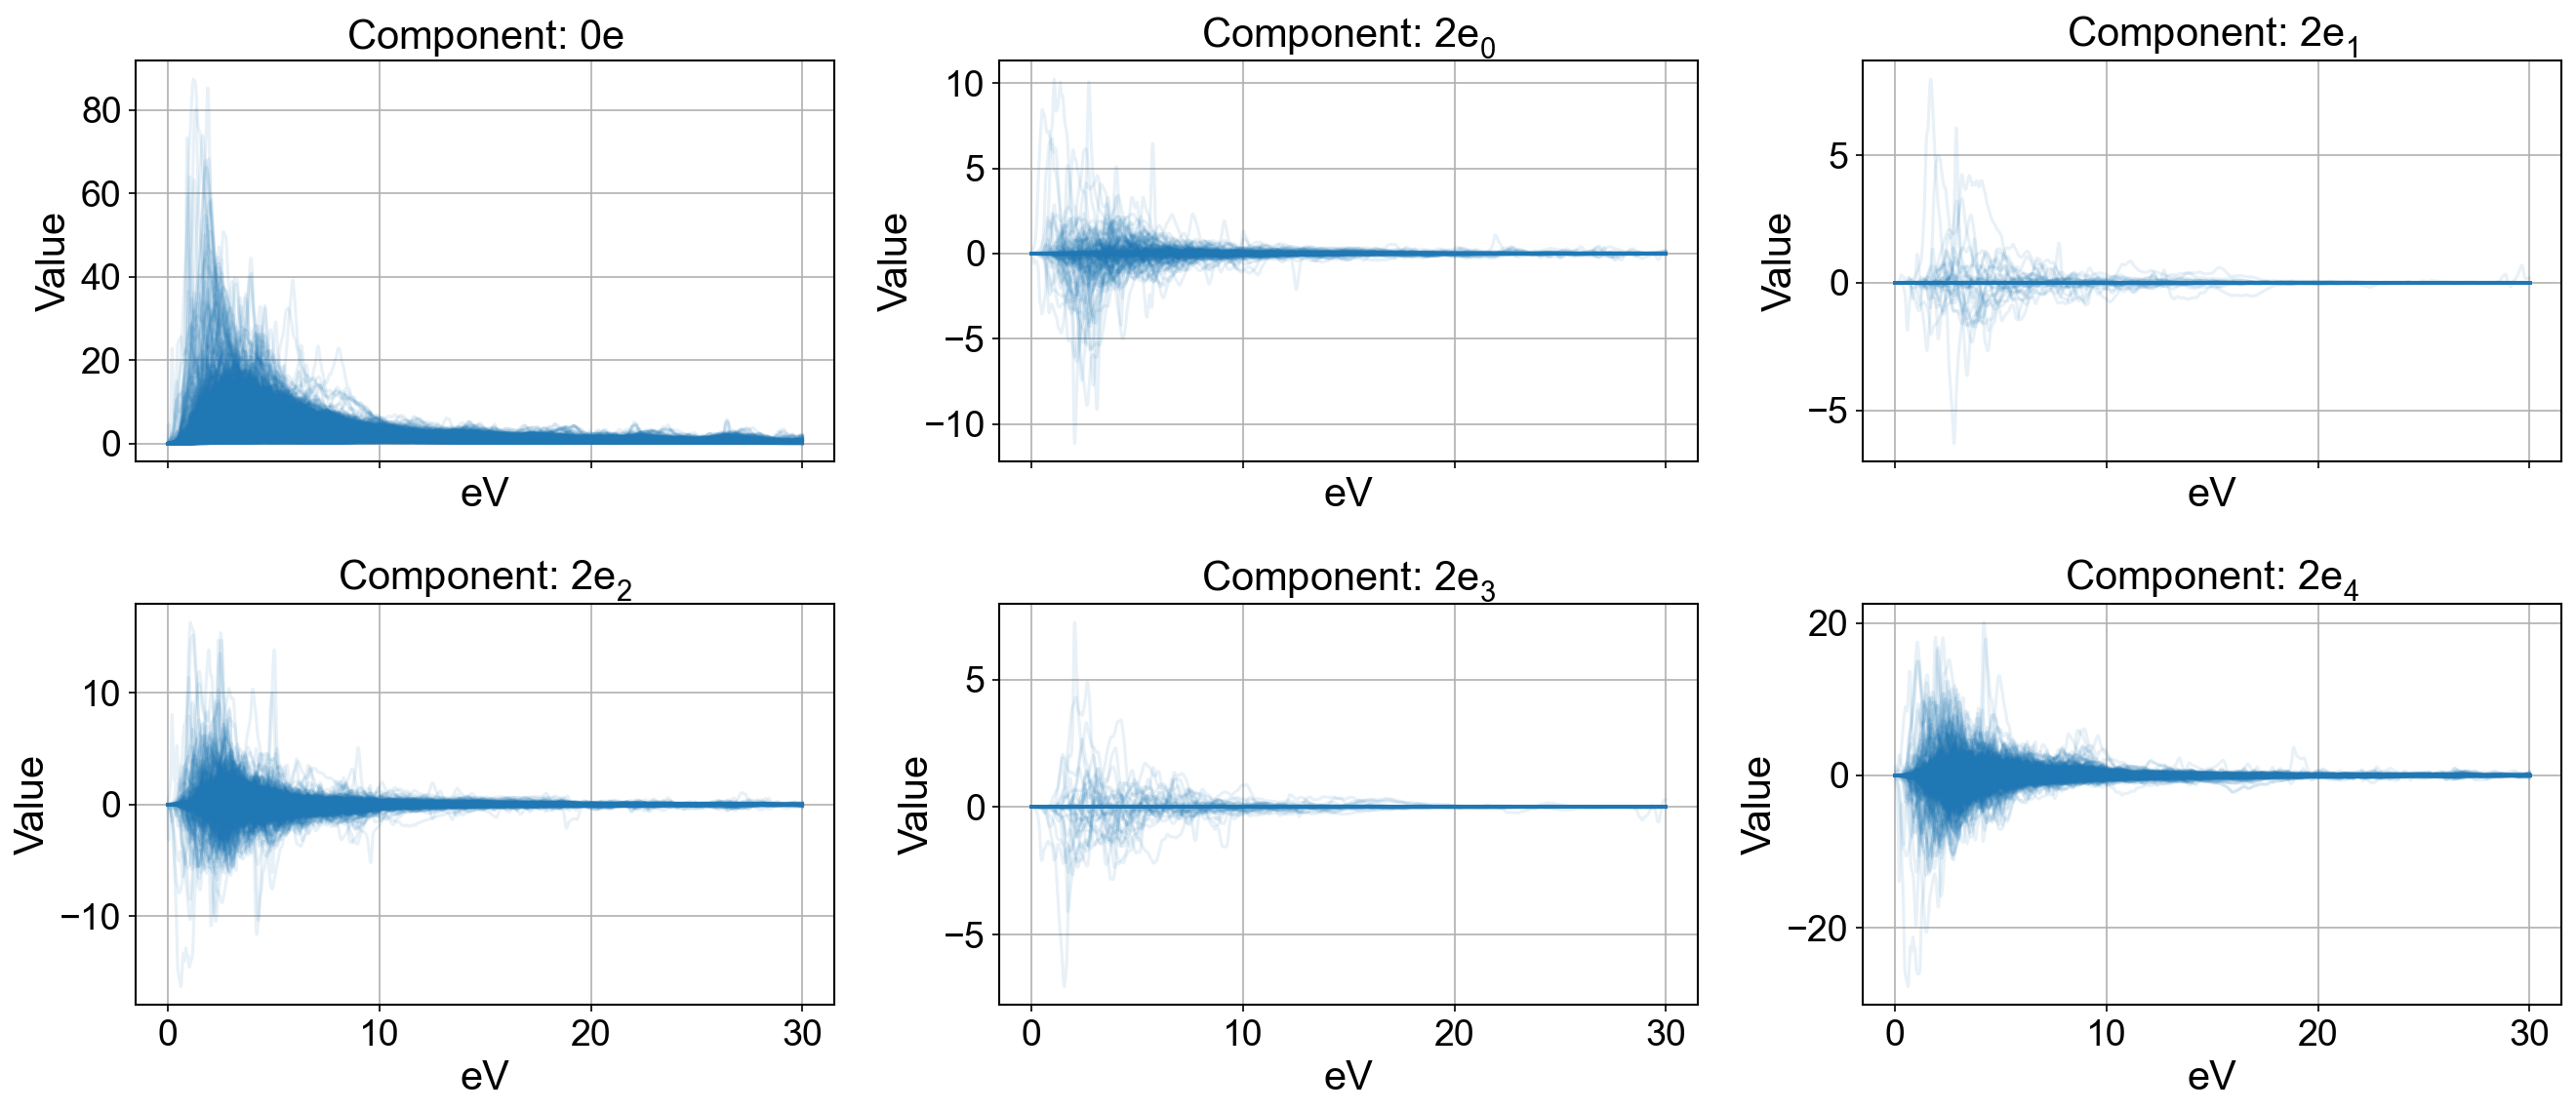

In [9]:
stack_matrices_tensor = torch.tensor(np.stack(df['rel_permittivity_imag'].values), dtype=torch.float64, device=device)  # Shape: (num_samples, 301, 3, 3)

# Transform Cartesian tensor to irreps
x = CartesianTensor("ij=ji")  # Symmetric rank-2 tensor
sph_coefs_tensor = x.from_cartesian(stack_matrices_tensor)  # Shape: (num_samples, 301, 6)
# Labels (optional)
channel_labels = ["0e", "2e_0", "2e_1", "2e_2", "2e_3", "2e_4"]

# Frequency axis
freqs = np.linspace(0, 30, 3001)  # replace with your actual energy or omega grid
# Plotting
fig, axes = plt.subplots(2, 3, figsize=(18, 8), dpi=150, sharex=True)
axes = axes.flatten()

for i in range(6):
    ax = axes[i]
    ax.plot(freqs, sph_coefs_tensor[:, :, i].T.cpu().numpy(), alpha=0.1, color='C0')  # each sample = one line
    ax.set_title(rf"Component: ${channel_labels[i]}$")
    ax.set_xlabel("eV")
    ax.set_ylabel("Value")
    ax.grid(True)

plt.tight_layout()
plt.show()


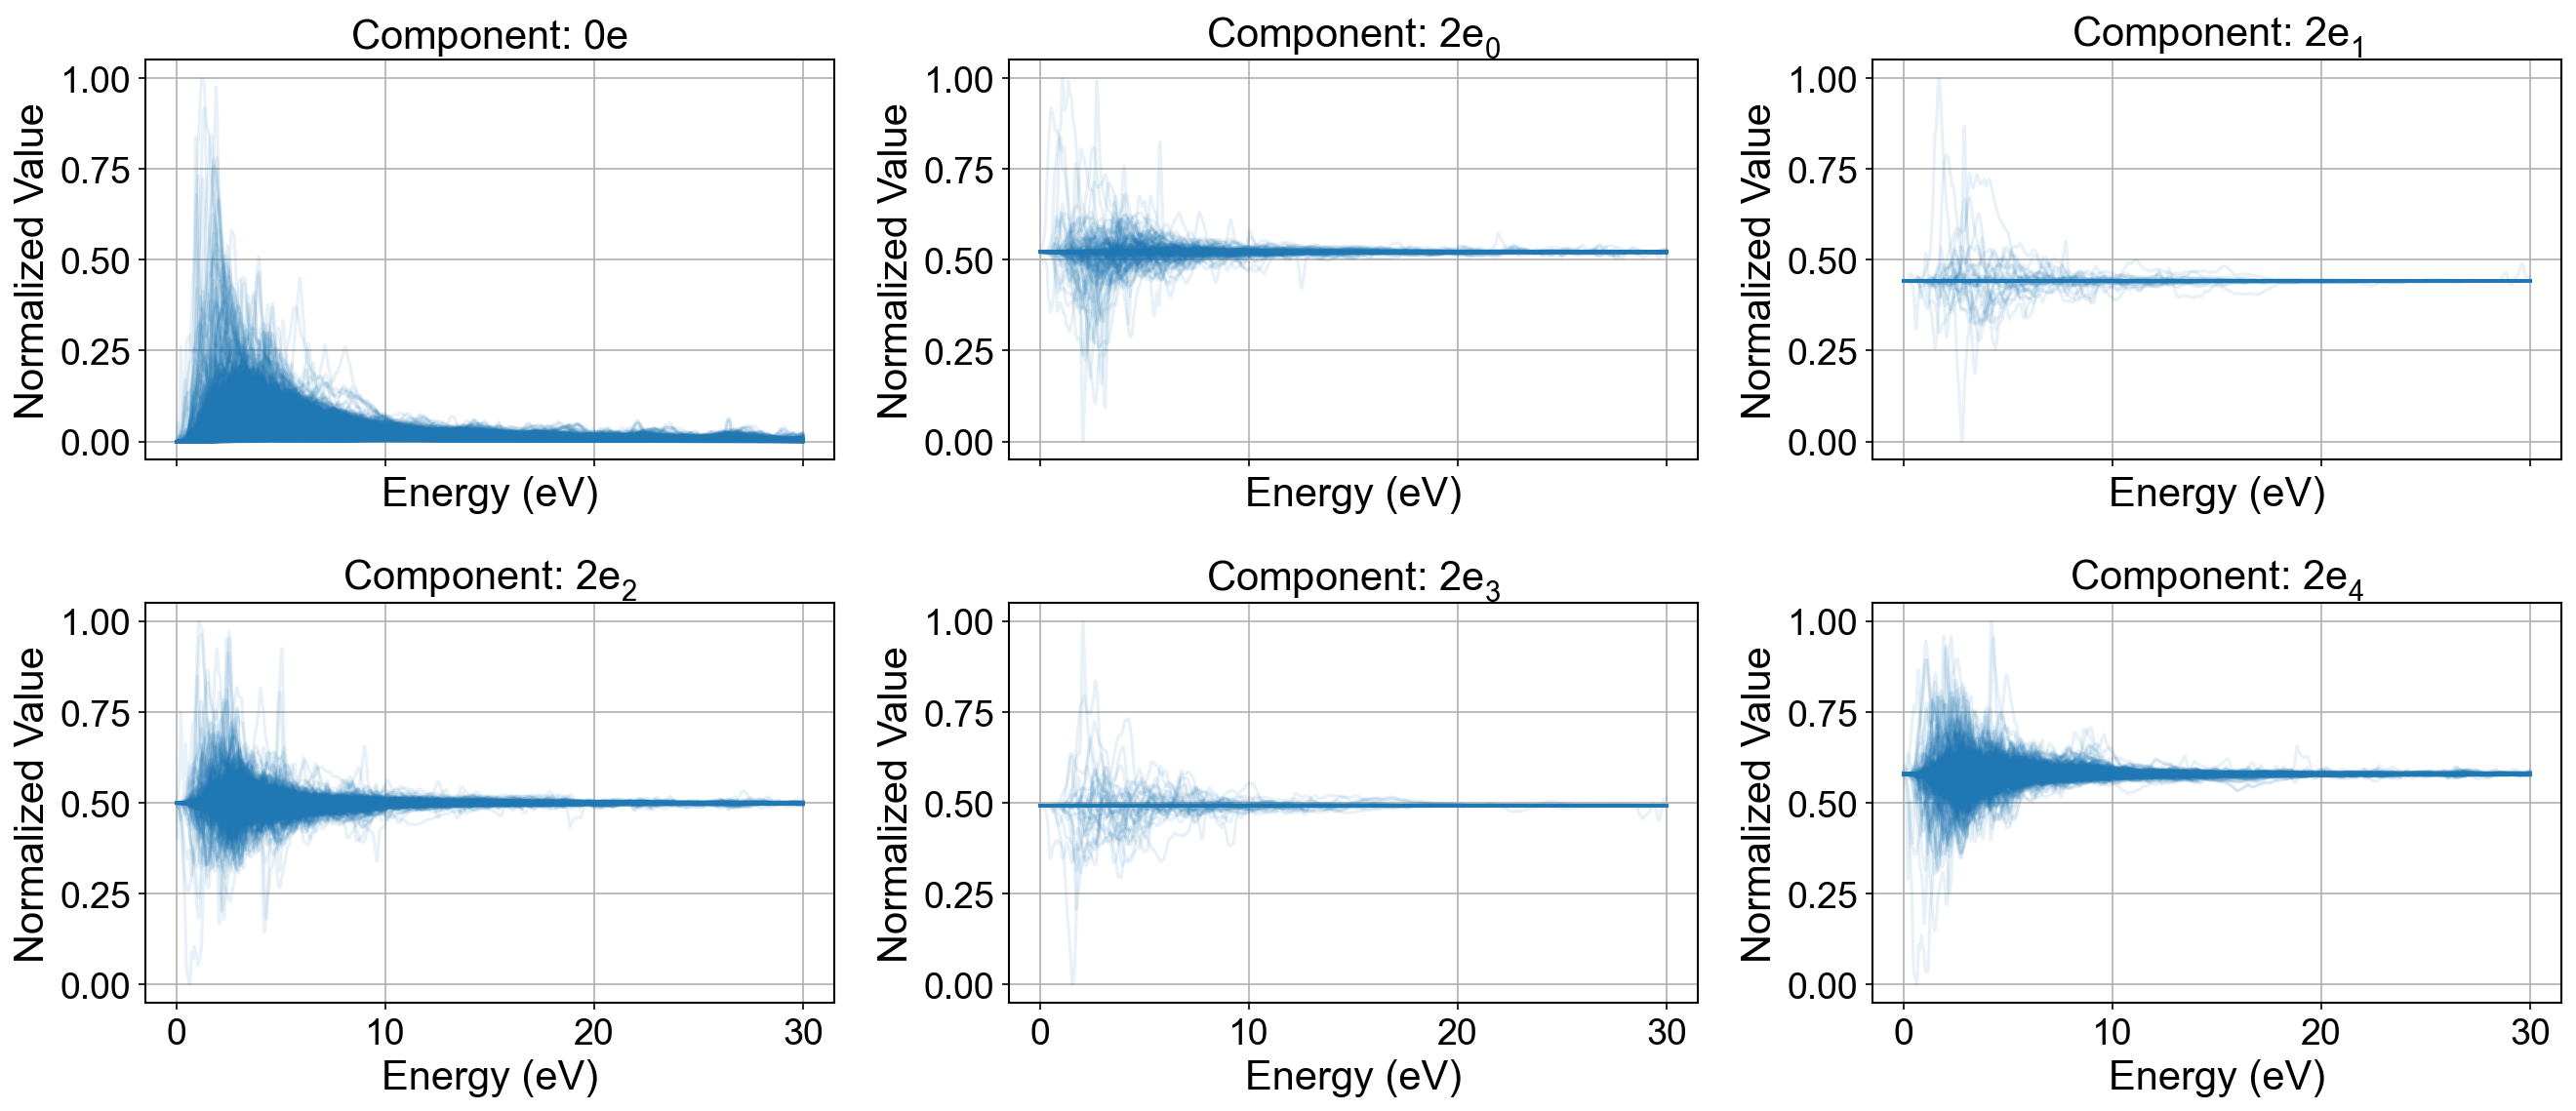

In [10]:
# Step 1: Transform Cartesian → spherical irreps
stack_matrices_tensor = torch.tensor(
    np.stack(df['rel_permittivity_imag'].values),
    dtype=torch.float64,
    device=device
)  # (N, F, 3, 3)

x = CartesianTensor("ij=ji")
sph_coefs_tensor = x.from_cartesian(stack_matrices_tensor)  # (N, F, 6)
df['sph_coefs'] = list(sph_coefs_tensor.cpu().numpy())

# Step 2: Flatten across samples and frequencies
sph_flat = sph_coefs_tensor.view(-1, 6)  # (N*F, 6)

# Step 3: Compute min and max per spherical channel
sph_min = torch.amin(sph_flat, dim=0)  # (6,)
sph_max = torch.amax(sph_flat, dim=0)  # (6,)

# Step 4: Min–max normalization
eps = 1e-12
sph_normalized = (sph_coefs_tensor - sph_min.view(1, 1, 6)) / (
    (sph_max - sph_min + eps).view(1, 1, 6)
)  # (N, F, 6)

# Step 5: Plot normalized spherical coefficients
channel_labels = ["0e", "2e_0", "2e_1", "2e_2", "2e_3", "2e_4"]
freqs = np.linspace(0, 30, sph_coefs_tensor.shape[1])

fig, axes = plt.subplots(2, 3, figsize=(18, 8), dpi=150, sharex=True)
axes = axes.flatten()

for i in range(6):
    ax = axes[i]
    ax.plot(freqs, sph_normalized[:, :, i].T.cpu().numpy(), alpha=0.1, color='C0')
    ax.set_title(rf"Component: ${channel_labels[i]}$")
    ax.set_xlabel("Energy (eV)")
    ax.set_ylabel("Normalized Value")
    ax.grid(True)

plt.tight_layout()
plt.show()


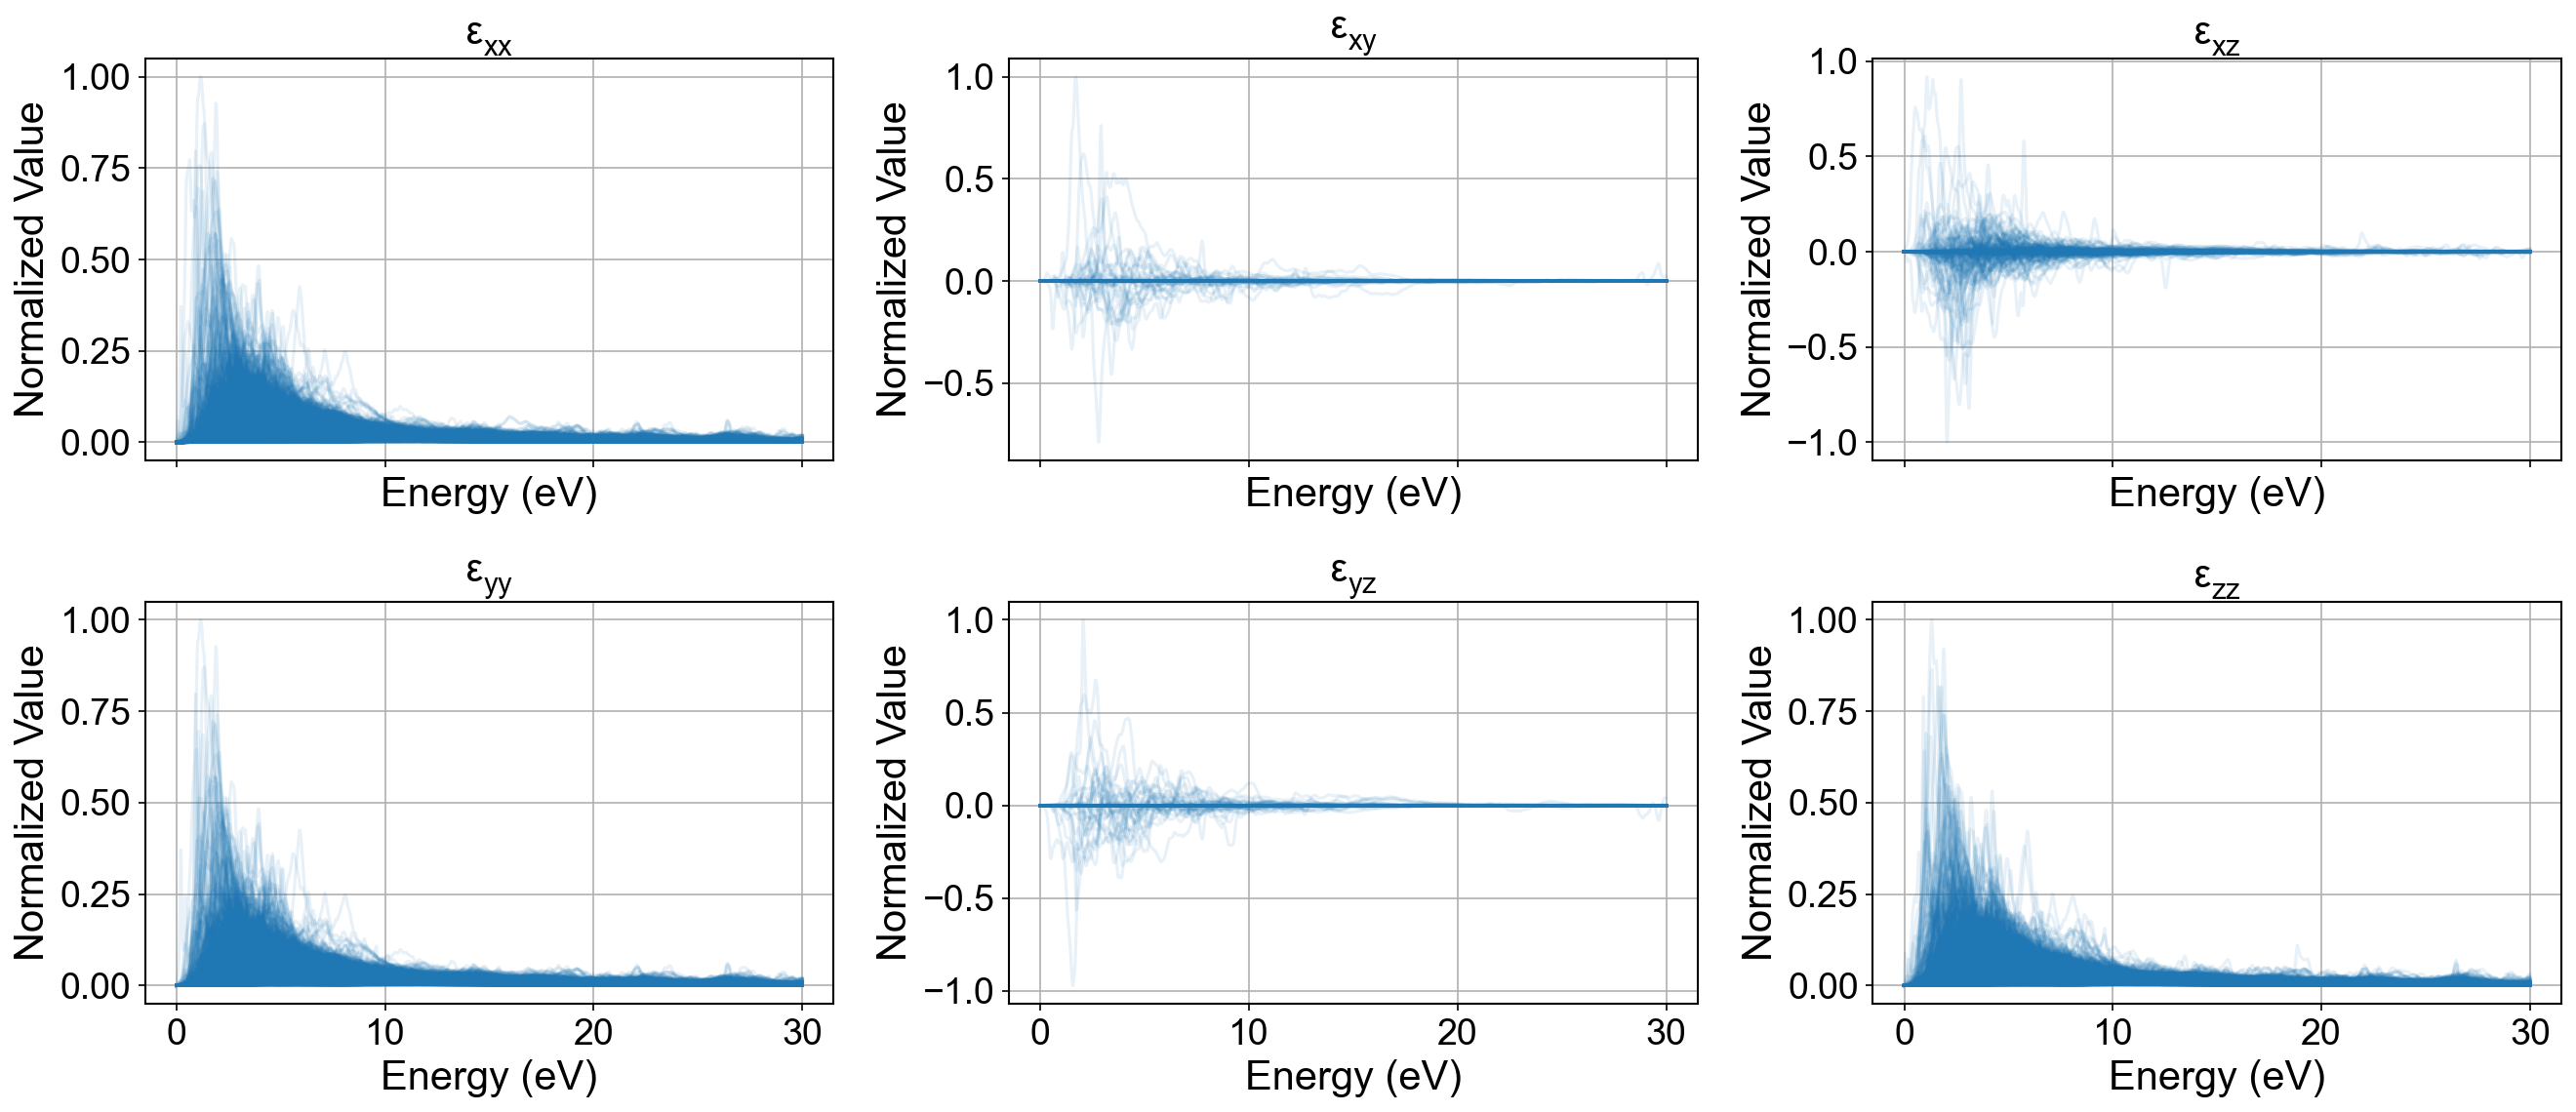

In [11]:
import torch
import matplotlib.pyplot as plt

# stack_matrices_tensor: (N, F, 3, 3)
# freqs: (F,)
xyz = ["x", "y", "z"]
# Input: (N, F, 3, 3)
eps = stack_matrices_tensor.clone()

# Normalized output
eps_norm = torch.zeros_like(eps)

# Store normalization parameters
norm_params = torch.zeros((3, 3, 2))  
# convention:
#   for diagonals: [min, max]
#   for off-diagonals: [0, max_abs]

for i in range(3):
    for j in range(3):
        comp = eps[:, :, i, j]

        if i == j:  # diagonal → [0, 1]
            min_val = comp.min()
            max_val = comp.max()
            eps_norm[:, :, i, j] = (comp - min_val) / (max_val - min_val + 1e-8)
            norm_params[i, j, 0] = min_val
            norm_params[i, j, 1] = max_val
        else:  # off-diagonal → [-1, 1]
            max_abs = comp.abs().max()
            eps_norm[:, :, i, j] = comp / (max_abs + 1e-8)
            norm_params[i, j, 0] = 0.0
            norm_params[i, j, 1] = max_abs

# --- Plotting ---
fig, axes = plt.subplots(2, 3, figsize=(18, 8), dpi=150, sharex=True)
axes = axes.flatten()

plot_idx = 0
for i in range(3):
    for j in range(i, 3):
        ax = axes[plot_idx]
        ax.plot(freqs, eps_norm[:, :, i, j].T.cpu().numpy(), alpha=0.1, color='C0')  # each sample = one line
        ax.set_title(rf"$\epsilon_{{{xyz[i]}{xyz[j]}}}$")
        ax.set_xlabel("Energy (eV)")
        ax.set_ylabel("Normalized Value")
        ax.grid(True)
        plot_idx += 1

plt.tight_layout()
plt.show()


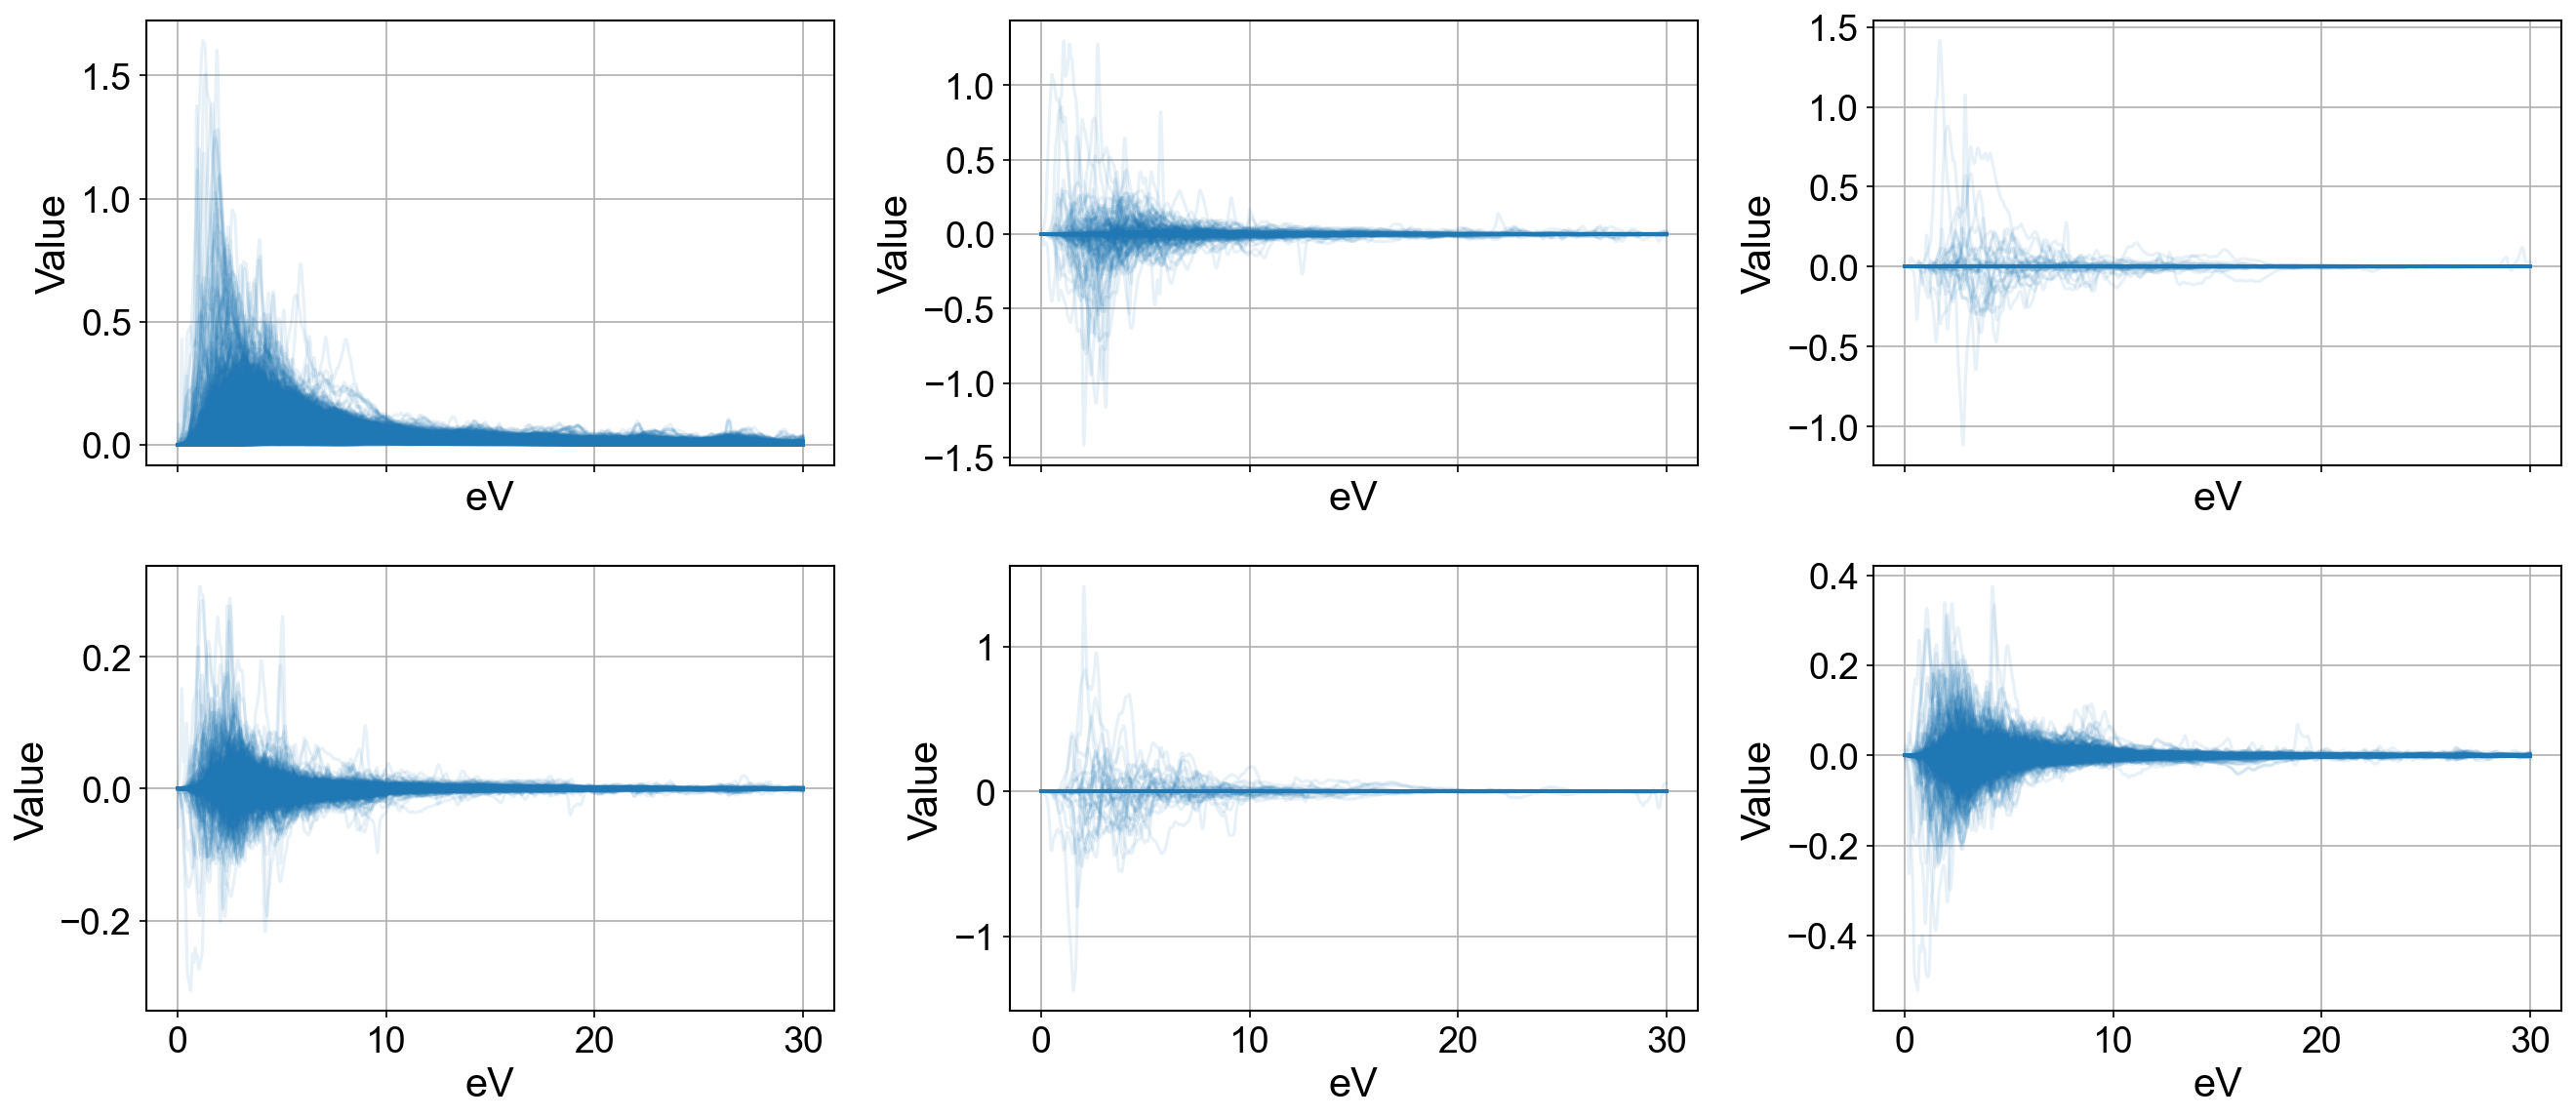

In [12]:
def normalize_with_params(eps, norm_params):
    eps_norm = torch.zeros_like(eps)
    for i in range(3):
        for j in range(3):
            comp = eps[:, :, i, j]
            min_val, max_val = norm_params[i, j]
            if i == j:  # diagonal
                eps_norm[:, :, i, j] = (comp - min_val) / (max_val - min_val + 1e-8)
            else:  # off-diagonal
                eps_norm[:, :, i, j] = comp / (max_val + 1e-8)
    return eps_norm

def denormalize(eps_norm, norm_params):
    eps_recon = torch.zeros_like(eps_norm)
    for i in range(3):
        for j in range(3):
            min_val, max_val = norm_params[i, j]
            if i == j:  # diagonal
                eps_recon[:, :, i, j] = eps_norm[:, :, i, j] * (max_val - min_val) + min_val
            else:  # off-diagonal
                eps_recon[:, :, i, j] = eps_norm[:, :, i, j] * max_val
    return eps_recon

x = CartesianTensor("ij=ji")
sph_coefs_tensor = x.from_cartesian(eps_norm)  # (N, F, 6)
fig, axes = plt.subplots(2, 3, figsize=(18, 8), dpi=150, sharex=True)
axes = axes.flatten()

for i in range(6):
    ax = axes[i]
    ax.plot(freqs, sph_coefs_tensor[:, :, i].T.cpu().numpy(), alpha=0.1, color='C0')  # each sample = one line
    ax.set_xlabel("eV")
    ax.set_ylabel("Value")
    ax.grid(True)

plt.tight_layout()
plt.show()

formula                                                                    Cl6Li15N3
symmetrized_structure              (Atom('Li', [4.554874995695477e-17, 2.08735216...
mp_id                                                                       mp-29151
bandgap_openmx                                                              2.425501
bandgap_mp                                                                    1.9425
bandgap_type                                                                Indirect
crystal_system                                                              trigonal
omega                              [0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07...
species                                                                  [Li, N, Cl]
real_symmetrized_susceptibility    [[[1.4076252798775462, 4.2789845740761244e-17,...
imag_symmetrized_susceptibility    [[[7.530597849931237e-19, -1.2839532962581572e...
rotation_matrices                  [[[1.0, 5.169833723804975e-17,

<Figure size 1000x800 with 0 Axes>

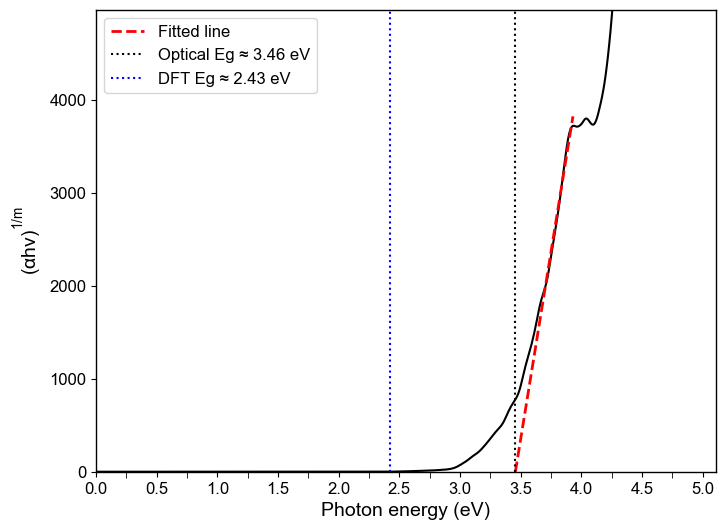

Provided Eg = 2.43 eV
Estimated optical Eg (Tauc fit) = 3.46 eV


In [29]:
from scipy.stats import linregress
from scipy.signal import argrelextrema
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

def absorption_coef(omega, epsilon_1, epsilon_2):
    return np.sqrt(2) * 5.067726 * omega * np.sqrt(np.sqrt(epsilon_1**2 + epsilon_2**2) - epsilon_1)
    # return np.sqrt(2) * omega * np.sqrt(np.sqrt(epsilon_1**2 + epsilon_2**2) - epsilon_1)

def derive_optical_functions(omega, epsilon_1, epsilon_2):
    """
    From dielectric function (Re1, Im1) compute:
      n(ω), k(ω), absorption α(ω), loss function L(ω), reflectance R(ω).
    Returns dict of arrays with same length as omega.
    """
    epsilon_1 = np.asarray(epsilon_1); epsilon_2 = np.asarray(epsilon_2)
    omega = np.asarray(omega)

    # n, k from ε1, ε2
    eps_abs = np.sqrt(epsilon_1**2 + epsilon_2**2)
    n = np.sqrt(0.5 * (eps_abs + epsilon_1))
    k = np.sqrt(np.maximum(0.0, 0.5 * (eps_abs - epsilon_1)))

    # Absorption α(ω) = 2ωk / c   (with ω in rad/s)
    hbar = 6.582119569e-16  # eV*s
    c = 2.99792458e8        # m/s
    omega_rad = omega / hbar
    alpha = 2 * omega_rad * k / c  # 1/m

    # Loss function
    L = epsilon_2 / (epsilon_1**2 + epsilon_2**2 + 1e-300)

    # Reflectance (normal incidence)
    R = ((n - 1)**2 + k**2) / ((n + 1)**2 + k**2)

    return {"n": n, "k": k, "alpha": alpha, "L": L, "R": R}

def find_peak_LHS_from_Eg(energy, alpha, Eg, m=0.5, frac_level=0.3):
    y = (alpha * energy) ** (1/m)

    # Find local maxima after Eg
    idx_peaks = argrelextrema(y, np.greater)[0]
    idx_peaks = idx_peaks[energy[idx_peaks] > Eg]

    if len(idx_peaks) == 0:
        return (Eg, Eg + 0.5)  # fallback

    # First absorption peak
    idx_peak = idx_peaks[0] - 1
    E_peak, y_peak = energy[idx_peak], y[idx_peak]

    # LHS cutoff: first point where y < frac_level * y_peak
    lhs_candidates = np.where((energy < E_peak) & (y < frac_level * y_peak))[0]
    if len(lhs_candidates) == 0:
        Emin = Eg
    else:
        Emin = energy[lhs_candidates[-1]]  # closest from left

    return (Emin, E_peak)
def tauc_fit(energy, alpha, m=0.5, Eg_dft=None, fit_range=None, plot=True, label="Direct allowed",
             figsize=(8,6), fontsize=14):
    y = (alpha * energy) ** (1/m)

    if fit_range is None:
        raise ValueError("fit_range must be provided when Eg is known")

    mask = (energy >= fit_range[0]) & (energy <= fit_range[1])
    E_fit, y_fit = energy[mask], y[mask]
    if len(E_fit) < 2:
        raise ValueError(f"No points in fit_range {fit_range}")

    # Linear regression
    slope, intercept, _, _, _ = linregress(E_fit, y_fit)
    Eg_opt = -intercept / slope

    if plot:
        fig, ax = plt.subplots(figsize=figsize)

        # Raw Tauc curve
        ax.plot(energy, y, lw=1.5, color='black')

        # Fitted line
        E_line = np.linspace(Eg_opt, max(E_fit), 200)
        y_line = slope * E_line + intercept
        ax.plot(E_line, y_line, "r--", lw=2, label="Fitted line")

        # Vertical bandgaps
        ax.axvline(Eg_opt, color="k", linestyle=":", lw=1.5,
                   label=f"Optical Eg ≈ {Eg_opt:.2f} eV")
        if Eg_dft is not None:
            ax.axvline(Eg_dft, color="blue", linestyle=":", lw=1.5,
                       label=f"DFT Eg ≈ {Eg_dft:.2f} eV")

        # Labels
        ax.set_xlabel("Photon energy (eV)", fontsize=fontsize)
        ax.set_ylabel(r"$(\alpha h\nu)^{1/m}$", fontsize=fontsize)
        ax.set_xlim(0, 1.3 * fit_range[1])
        ax.set_ylim(0, 1.3 * max(y_line))

        # Major + minor ticks
        ax.xaxis.set_major_locator(ticker.MultipleLocator(0.5))
        ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(2))  # adds 0.25 ticks
        ax.tick_params(axis="both", which="major", labelsize=fontsize-2)
        ax.tick_params(axis="both", which="minor", length=4, labelsize=0)  # hide labels for minor ticks

        # Legend
        ax.legend(fontsize=fontsize-2,loc="upper left", frameon=True)
        plt.show()

    return Eg_opt

row = df.sample(1).iloc[0]
print(row)
energy = np.array(row.omega)  # in eV
Re_eps = np.array(row.rel_permittivity_real)
Im_eps = np.array(row.rel_permittivity_imag)
eps1 = np.mean(Re_eps[:, [0,1,2], [0,1,2]], axis=1)
eps2 = np.mean(Im_eps[:, [0,1,2], [0,1,2]], axis=1)

alpha = absorption_coef(energy, eps1, eps2)

# Eg provided (DFT or reference)
Eg_input = row.bandgap_openmx  

# Find fit range dynamically from Eg
# fit_range = find_peak_LHS_from_Eg(energy, alpha, Eg=Eg_input, m=0.5, back_window=0.2)
fit_range = find_peak_LHS_from_Eg(energy, alpha, Eg=Eg_input, m=0.5, frac_level=0.5)
plt.figure(figsize=(10,8))
Eg_fit = tauc_fit(energy, alpha, m=0.5, Eg_dft = Eg_input, fit_range=fit_range, label="Direct allowed")
plt.show()
print(f"Provided Eg = {Eg_input:.2f} eV")
print(f"Estimated optical Eg (Tauc fit) = {Eg_fit:.2f} eV")

R² = -1.171


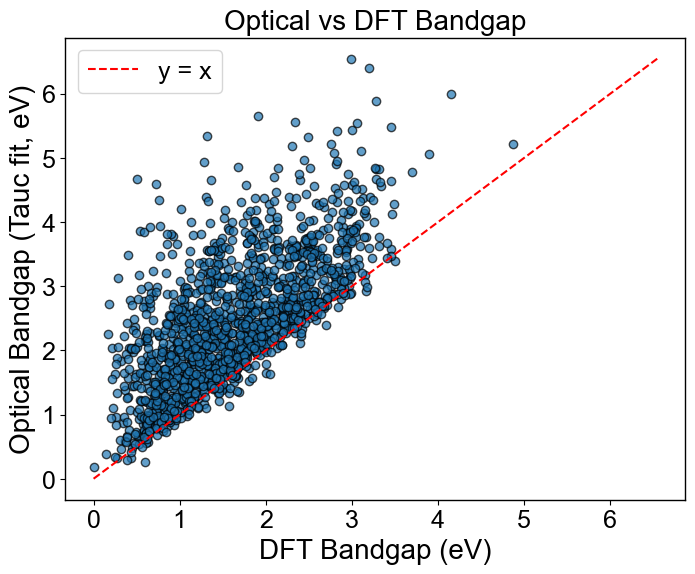

In [182]:
optical_Egs = []
alphas = []

for idx, row in df.iterrows():
    try:
        energy = np.array(row.omega)  # in eV
        Re_eps = np.array(row.rel_permittivity_real)
        Im_eps = np.array(row.rel_permittivity_imag)

        eps1 = np.mean(Re_eps[:, [0,1,2], [0,1,2]], axis=1)
        eps2 = np.mean(Im_eps[:, [0,1,2], [0,1,2]], axis=1)

        alpha = absorption_coef(energy, eps1, eps2)
        alphas.append(alpha)  # store alpha spectrum

        Eg_input = row.bandgap_openmx  # provided (DFT or reference)

        fit_range = find_peak_LHS_from_Eg(
            energy, alpha, Eg=Eg_input, m=0.5, frac_level=0.5
        )

        Eg_fit = tauc_fit(
            energy, alpha, m=0.5, fit_range=fit_range, plot=False, label="Direct allowed"
        )

        optical_Egs.append(Eg_fit)
    except Exception as e:
        print(f"Row {idx} failed: {e}")
        optical_Egs.append(np.nan)
        alphas.append(np.nan)

# Store results in df
df["optical_bandgap"] = optical_Egs
df["alpha"] = alphas  # each entry is a numpy array of α(ω)
from sklearn.metrics import r2_score

mask = df["optical_bandgap"].notna() & df["bandgap_openmx"].notna()
x = df.loc[mask, "bandgap_openmx"].values
y = df.loc[mask, "optical_bandgap"].values

# Scatter plot
plt.figure(figsize=(8,6))
plt.scatter(x, y, alpha=0.7, edgecolor="k")

# Add y=x reference line
print(f"R² = {r2_score(x, y):.3f}")
lims = [min(x.min(), y.min()), max(x.max(), y.max())]
plt.plot(lims,lims, "r--", label="y = x")
plt.xlabel("DFT Bandgap (eV)")
plt.ylabel("Optical Bandgap (Tauc fit, eV)")
plt.title(f"Optical vs DFT Bandgap")
plt.legend()
plt.show()


Plasma freq (loss peak): 7.1
Nearest ε1=0: None
Reflectance edge: 7.11


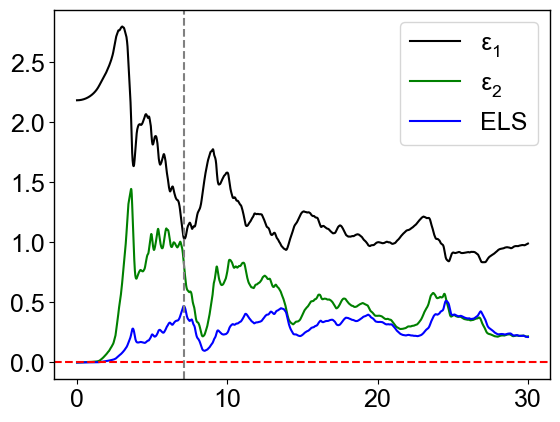

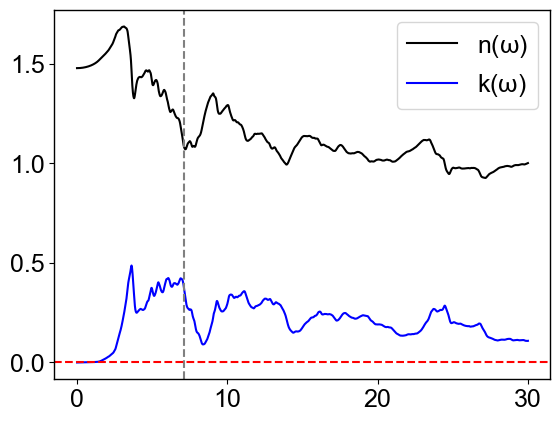

In [16]:
from scipy.signal import find_peaks
row = df.sample(1).iloc[0]
energy = np.array(row.omega)  # in eV
Re_eps = np.array(row.rel_permittivity_real)
Im_eps = np.array(row.rel_permittivity_imag)
eps1 = np.mean(Re_eps[:, [0,1,2], [0,1,2]], axis=1)
eps2 = np.mean(Im_eps[:, [0,1,2], [0,1,2]], axis=1)

derived = derive_optical_functions(energy, eps1, eps2)
n = derived["n"]
k = derived["k"]
alpha = derived["alpha"]
loss = derived["L"]
R = derived["R"]

def find_plasmon(omega, Re1, Im1, prominence=0.02, window_ev=1.0, max_eps2=5.0):
    """Identify plasma frequency from loss peak, nearest ε1=0, and reflectance edge."""
    L = Im1 / (Re1**2 + Im1**2 + 1e-300)
    peaks, props = find_peaks(L, prominence=prominence)
    if peaks.size == 0:
        return {'omega_p_loss': None, 'omega_p_zero': None, 'omega_edge_R': None}

    # pick strongest peak (by prominence, then by damping)
    order = np.argsort(-props['prominences'])
    idx_peak = peaks[order[0]]
    w_peak = omega[idx_peak]
    for k in order:
        ip = peaks[k]
        if Im1[ip] <= max_eps2:
            idx_peak = ip; w_peak = omega[ip]; break

    # nearest zero crossing of ε1
    mask = (omega >= w_peak - window_ev) & (omega <= w_peak + window_ev)
    w_local, e_local = omega[mask], Re1[mask]
    zero_w = None
    if len(w_local) >= 2:
        sgn = np.sign(e_local)
        flips = np.where(sgn[:-1] * sgn[1:] < 0)[0]
        if len(flips):
            j = flips[np.argmin(np.abs((w_local[flips]+w_local[flips+1])/2 - w_peak))]
            x0, x1, y0, y1 = w_local[j], w_local[j+1], e_local[j], e_local[j+1]
            zero_w = x0 - y0*(x1-x0)/(y1-y0)

    # reflectance edge: sharpest drop
    R = ((np.sqrt(0.5*(np.sqrt(Re1**2+Im1**2)+Re1)) - 1)**2 +
         (np.sqrt(np.maximum(0.0,0.5*(np.sqrt(Re1**2+Im1**2)-Re1))))**2) / \
        ((np.sqrt(0.5*(np.sqrt(Re1**2+Im1**2)+Re1)) + 1)**2 +
         (np.sqrt(np.maximum(0.0,0.5*(np.sqrt(Re1**2+Im1**2)-Re1))))**2)
    dR = np.gradient(R, omega)
    mask2 = (omega >= w_peak - window_ev) & (omega <= w_peak + window_ev)
    edge_w = omega[mask2][np.argmin(dR[mask2])] if np.any(mask2) else None

    return {'omega_p_loss': float(w_peak),
            'omega_p_zero': None if zero_w is None else float(zero_w),
            'omega_edge_R': None if edge_w is None else float(edge_w)}

# Find plasmon characteristics
res = find_plasmon(energy, eps1, eps2)
print("Plasma freq (loss peak):", res['omega_p_loss'])
print("Nearest ε1=0:", res['omega_p_zero'])
print("Reflectance edge:", res['omega_edge_R'])

plt.plot(energy, eps1, color ='black', label = r'$\epsilon_1$')
plt.plot(energy, eps2, color ='green', label = r'$\epsilon_2$')
plt.plot(energy, loss, color='blue', label =r'ELS')
plt.axvline(res['omega_p_loss'], ymin = min(loss), ymax = max(eps1), color = 'grey', linestyle ='--')
plt.axhline(0, xmin=min(energy), xmax= max(energy), color = 'red', linestyle ='--')
plt.legend()
plt.show()

plt.plot(energy, n, color='black', label = r'$n(\omega)$')
plt.plot(energy, k, color='blue', label = r'$k(\omega)$')
plt.axvline(res['omega_p_loss'], ymin = min(k), ymax = max(n), color = 'grey', linestyle ='--')
plt.axhline(0, xmin=min(energy), xmax= max(energy), color = 'red', linestyle ='--')
plt.legend()
plt.show()

In [17]:
def iso_or_longitudinal_eps(Re_eps_F33, Im_eps_F33, qhat=None):
    """Average dielectric function (isotropic or longitudinal)."""
    Re = np.asarray(Re_eps_F33); Im = np.asarray(Im_eps_F33)
    if qhat is None:
        Re_iso = np.trace(Re, axis1=1, axis2=2) / 3.0
        Im_iso = np.trace(Im, axis1=1, axis2=2) / 3.0
        return Re_iso, Im_iso
    q = np.asarray(qhat); q = q / np.linalg.norm(q)
    Re_L = np.einsum('i,Fij,j->F', q, Re, q)
    Im_L = np.einsum('i,Fij,j->F', q, Im, q)
    return Re_L, Im_L

def find_plasmon(omega, Re1, Im1, prominence=0.02, window_ev=1.0, max_eps2=5.0):
    """Identify plasma frequency from loss peak, nearest ε1=0, and reflectance edge."""
    L = Im1 / (Re1**2 + Im1**2 + 1e-300)
    peaks, props = find_peaks(L, prominence=prominence)
    if peaks.size == 0:
        return None, None, None

    # pick strongest peak (by prominence, then by damping)
    order = np.argsort(-props['prominences'])
    idx_peak = peaks[order[0]]
    w_peak = omega[idx_peak]
    for k in order:
        ip = peaks[k]
        if Im1[ip] <= max_eps2:
            idx_peak = ip; w_peak = omega[ip]; break

    # nearest zero crossing of ε1
    mask = (omega >= w_peak - window_ev) & (omega <= w_peak + window_ev)
    w_local, e_local = omega[mask], Re1[mask]
    zero_w = None
    if len(w_local) >= 2:
        sgn = np.sign(e_local)
        flips = np.where(sgn[:-1] * sgn[1:] < 0)[0]
        if len(flips):
            j = flips[np.argmin(np.abs((w_local[flips]+w_local[flips+1])/2 - w_peak))]
            x0, x1, y0, y1 = w_local[j], w_local[j+1], e_local[j], e_local[j+1]
            zero_w = x0 - y0*(x1-x0)/(y1-y0)

    return float(w_peak), None if zero_w is None else float(zero_w), None

# ====================================================
# Iterate over df and store ωp
# ====================================================
omega_p_loss_list = []
omega_p_zero_list = []

for _, row in df.iterrows():
    omega = np.array(row['omega'])
    Re_eps = np.array(row['rel_permittivity_real'])
    Im_eps = np.array(row['rel_permittivity_imag'])

    # isotropic average
    Re1, Im1 = iso_or_longitudinal_eps(Re_eps, Im_eps, qhat=None)

    w_loss, w_zero, _ = find_plasmon(omega, Re1, Im1)
    omega_p_loss_list.append(w_loss)

# Store in df
df['omega_p_loss'] = omega_p_loss_list

print(df['omega_p_loss'].head())

0    12.63
1    15.65
2    12.47
3    12.68
4    11.33
Name: omega_p_loss, dtype: float64


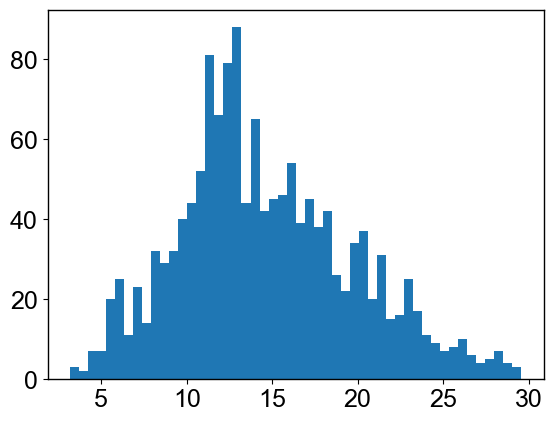

In [18]:
plt.hist(df['omega_p_loss'],bins=50)
plt.show()

In [19]:
# df = df.drop(columns=["folder", "omega_p_zero", "sph_coefs", "alpha"])
df.head()
# df.to_pickle(data_file1)

,formula,symmetrized_structure,mp_id,bandgap_openmx,bandgap_mp,bandgap_type,crystal_system,omega,species,real_symmetrized_susceptibility,imag_symmetrized_susceptibility,rotation_matrices,rel_permittivity_real,rel_permittivity_imag,optical_bandgap,omega_p_loss,sph_coefs,alpha
0,Li4Se8Y4,"(Atom('Li', [2.8385500000000006, 0.0, 2.88335]...",mp-37879,1.399564,1.6604,Direct,tetragonal,"[0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07...","[Y, Li, Se]","[[[3.4812758467294405, 0.0, -2.584939414228211...","[[[-1.2523566768095863e-17, 0.0, -4.8148248609...","[[[1.0, 0.0, 0.0], [0.0, 1.0, 0.0], [0.0, 0.0,...","[[[4.4812758467294405, 0.0, -2.584939414228211...","[[[-1.2523566768095863e-17, 0.0, -4.8148248609...",2.408357,12.63,"[[-1.2531147297256284e-17, -6.809190618832222e...","[0.0, 4.706413357225592e-06, 1.882653112612986..."
1,Mo3S2Se4,"(Atom('Mo', [1.6365999999999998, 0.94489145055...",mp-1025906,0.654262,0.5619,Direct,trigonal,"[0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07...","[S, Mo, Se]","[[[5.124538605076387, 6.794333614242494e-18, 5...","[[[2.6245939830145304e-17, -2.5679065925163146...","[[[1.0, 3.969365967485894e-18, 0.0], [0.0, 1.0...","[[[6.124538605076387, 6.794333614242494e-18, 5...","[[[2.6245939830145304e-17, -2.5679065925163146...",2.272499,15.65,"[[3.3398662348797254e-17, -7.263136660087704e-...","[0.0, 9.92345235992808e-06, 3.9697938662466097..."
2,Li3NbS4,"(Atom('Li', [0.0, 0.0, 3.0251], index=0), Atom...",mp-755309,2.968668,2.8348,Indirect,cubic,"[0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07...","[Nb, Li, S]","[[[1.7313150452437125, -3.529303946892918e-23,...","[[[9.73175816465002e-19, 0.0, 0.0], [0.0, 9.73...","[[[1.0, 0.0, 0.0], [0.0, 1.0, 0.0], [0.0, 0.0,...","[[[2.7313150452437123, -3.529303946892918e-23,...","[[[9.73175816465002e-19, 0.0, 0.0], [0.0, 9.73...",3.005767,12.47,"[[1.6855899588147084e-18, 0.0, 0.0, 1.71347124...","[0.0, 2.1845188825675672e-06, 8.73836893674509..."
3,CdSe2Zn,"(Atom('Zn', [2.07525, 2.07525, 2.981], index=0...",mp-1017534,0.940717,0.7236,Direct,tetragonal,"[0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07...","[Cd, Zn, Se]","[[[3.2667200732203123, 0.0, 0.0], [0.0, 3.2667...","[[[-8.841535879698145e-18, 0.0, -9.62964972193...","[[[1.0, 0.0, 0.0], [0.0, 1.0, 0.0], [0.0, 0.0,...","[[[4.266720073220313, 0.0, 0.0], [0.0, 4.26672...","[[[-8.841535879698145e-18, 0.0, -9.62964972193...",1.186695,12.68,"[[-1.9136131483905478e-17, -1.3618381237664445...","[0.0, 7.2284263202963886e-06, 2.89189273367749..."
4,Al8Te12,"(Atom('Al', [-1.0110162555088607, 0.7063003620...",mp-1228524,1.460160,1.3222,Direct,monoclinic,"[0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07...","[Al, Te]","[[[3.57865600493003, 0.0, 0.0588499476841695],...","[[[-2.370171074423322e-18, 0.0, 3.360404376639...","[[[1.0, 0.0, 6.761473487721657e-17], [0.0, 1.0...","[[[4.57865600493003, 0.0, 0.0588499476841695],...","[[[-2.370171074423322e-18, 0.0, 3.360404376639...",3.335917,11.33,"[[4.730985781407694e-18, 4.752329444500851e-19...","[0.0, 5.645662759936369e-06, 2.258394227653212..."


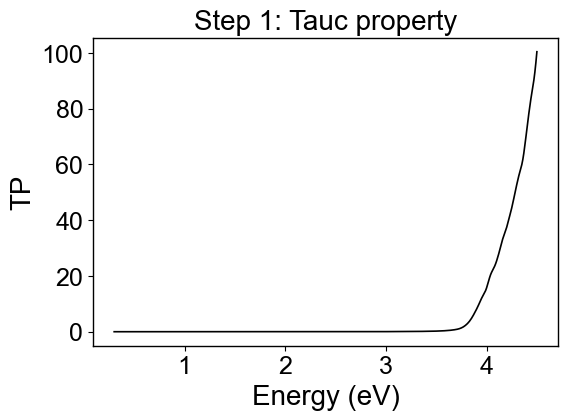

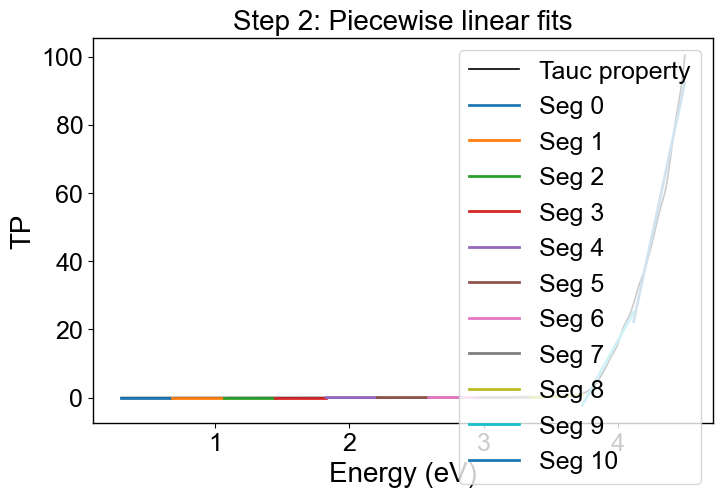

Segment slopes after merging:
  Seg 0: slope=0.0000, ΔTP=0.000, midpoint≈0.68 eV
  Seg 1: slope=0.0012, ΔTP=0.001, midpoint≈1.45 eV
  Seg 2: slope=0.0136, ΔTP=0.010, midpoint≈2.21 eV
  Seg 3: slope=0.0620, ΔTP=0.023, midpoint≈2.78 eV
  Seg 4: slope=0.2112, ΔTP=0.081, midpoint≈3.16 eV
  Seg 5: slope=2.1815, ΔTP=0.974, midpoint≈3.55 eV
  Seg 6: slope=71.4735, ΔTP=25.341, midpoint≈3.93 eV
  Seg 7: slope=183.5385, ΔTP=72.553, midpoint≈4.31 eV


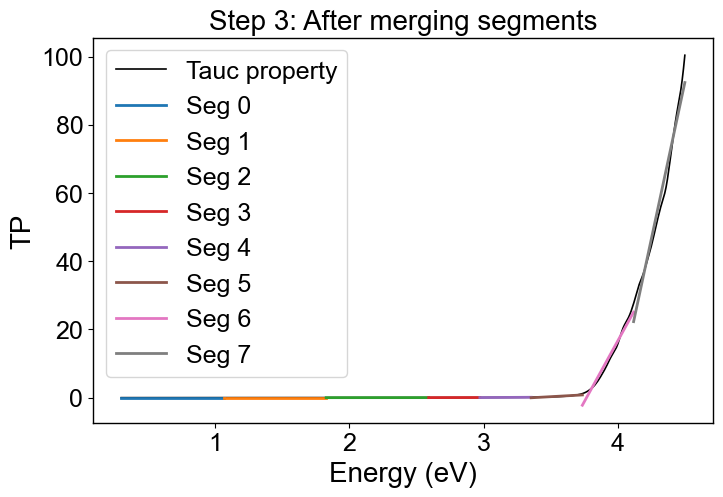

Detected slope jump at seg 4: slope 0.0620 → 0.2112 (Δ=0.1492)
Baseline seg = 3, Tauc seg = 4


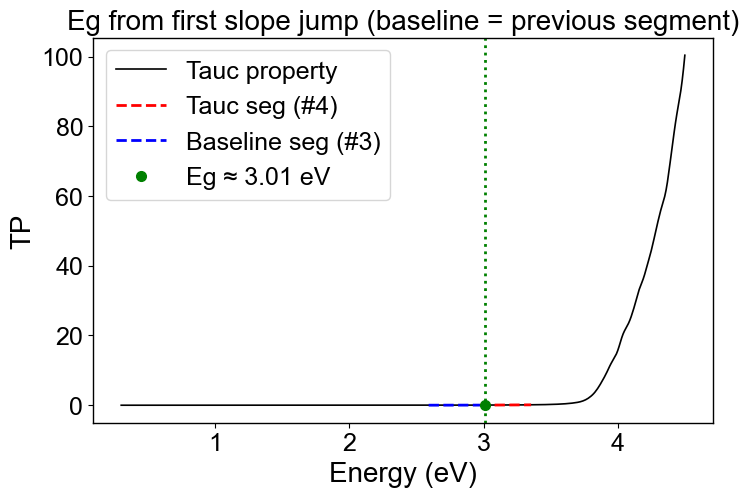

Provided Eg: 3.448803206437277
Estimated Eg(s): [3.0106872045023563]


In [111]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression

# ==============================
# Step 1: Tauc property (optionally normalized)
# ==============================
def tauc_property(energy, alpha, m=0.5, normalize=True):
    """
    Compute (α hν)^(1/m). If normalize=True, scale by max for stability.
    """
    tp = (alpha * energy) ** (1.0 / m)
    tp = np.clip(tp, 0.0, None)
    if normalize:
        vmax = tp.max() if tp.size else 1.0
        if vmax > 0:
            tp = tp / vmax
    return tp

# ==============================
# Step 2: Piecewise linear fit (uniform nodes)
# ==============================
def piecewise_linear_fit(E, TP, k=20):
    """
    Split spectrum into k+1 segments using k+2 uniformly spaced nodes.
    Fit Y = aX + b on each segment.
    """
    E = np.asarray(E); TP = np.asarray(TP)
    nodes = np.linspace(E[0], E[-1], k + 2)
    segs = []
    for i in range(len(nodes) - 1):
        mask = (E >= nodes[i]) & (E <= nodes[i + 1])
        X = E[mask].reshape(-1, 1)
        Y = TP[mask]
        if len(X) < 2:
            continue
        reg = LinearRegression().fit(X, Y)
        segs.append({
            "Emin": nodes[i],
            "Emax": nodes[i + 1],
            "slope": float(reg.coef_[0]),
            "intercept": float(reg.intercept_),
            "ΔTP": float(Y[-1] - Y[0])
        })
    return segs

# ==============================
# Step 3: Merge nearly-collinear neighbors
# ==============================
def merge_segments(segs, p3=0.03):
    """
    Merge adjacent segments whose slope difference is below p3.
    """
    if not segs:
        return []
    merged = []
    i = 0
    while i < len(segs) - 1:
        s1, s2 = segs[i], segs[i + 1]
        if abs(s1["slope"] - s2["slope"]) < p3:
            merged.append({
                "Emin": s1["Emin"],
                "Emax": s2["Emax"],
                "slope": 0.5 * (s1["slope"] + s2["slope"]),
                "intercept": 0.5 * (s1["intercept"] + s2["intercept"]),
                "ΔTP": s1["ΔTP"] + s2["ΔTP"],
            })
            i += 2
        else:
            merged.append(s1)
            i += 1
    if i == len(segs) - 1:
        merged.append(segs[-1])
    return merged

# ==============================
# NEW: Detect first significant slope jump
# ==============================
def detect_tauc_and_baseline(segs, slope_jump=0.05, dTP_min=0.001):
    """
    Find the first index i where slope[i] - slope[i-1] > slope_jump
    and the new segment has positive slope and non-trivial ΔTP.
    Returns ((i, seg_Tauc), (i-1, seg_Base)) or (None, None) if not found.
    """
    if len(segs) < 2:
        return None, None
    slopes = [s["slope"] for s in segs]
    for i in range(1, len(segs)):
        delta = slopes[i] - slopes[i - 1]
        if (delta > slope_jump) and (segs[i]["slope"] > 0.0) and (segs[i]["ΔTP"] > dTP_min):
            return (i, segs[i]), (i - 1, segs[i - 1])
    return None, None

# ==============================
# Step 6: Intersection -> Eg
# ==============================
def estimate_bandgap(seg_tauc, seg_base):
    """
    Eg from intersection of the two fitted lines.
    """
    aT, bT = seg_tauc["slope"], seg_tauc["intercept"]
    aB, bB = seg_base["slope"], seg_base["intercept"]
    if aT == aB:
        return None
    Eg = (bB - bT) / (aT - aB)
    return Eg

# ==============================
# Helper: visualize linear fits for segments list
# ==============================
def visualize_segments(E, TP, segs, title="Segments"):
    plt.figure(figsize=(8, 5))
    plt.plot(E, TP, 'k-', lw=1.2, label="Tauc property")
    colors = plt.cm.tab10.colors
    for i, s in enumerate(segs):
        xx = np.linspace(s["Emin"], s["Emax"], 80)
        yy = s["slope"] * xx + s["intercept"]
        plt.plot(xx, yy, color=colors[i % 10], lw=2, label=f"Seg {i}")
    plt.xlabel("Energy (eV)"); plt.ylabel("TP")
    plt.title(title); plt.legend(); plt.show()

# ==============================
# Debug driver (with slope-jump logic)
# ==============================
def suram_algorithm_debug(E, alpha, m=0.5, normalize_tp=False,
                          k_segments=20, merge_tol=0.03,
                          slope_jump=0.05, dTP_min=0.001):
    """
    Full debug routine:
    - builds TP (optionally normalized),
    - segments + merges,
    - prints slopes,
    - detects first slope jump to define (Tauc, Baseline),
    - plots everything and returns [Eg] or [].
    """
    # Step 1: TP
    TP = tauc_property(E, alpha, m=m, normalize=normalize_tp)
    plt.figure(figsize=(6, 4))
    plt.plot(E, TP, 'k-', lw=1.2)
    plt.title("Step 1: Tauc property")
    plt.xlabel("Energy (eV)"); plt.ylabel("TP")
    plt.show()

    # Step 2: raw segments
    segs = piecewise_linear_fit(E, TP, k=k_segments)
    visualize_segments(E, TP, segs, "Step 2: Piecewise linear fits")

    # Step 3: merged segments + printed slopes
    merged = merge_segments(segs, p3=merge_tol)
    print("Segment slopes after merging:")
    for i, s in enumerate(merged):
        mid = 0.5 * (s["Emin"] + s["Emax"])
        print(f"  Seg {i}: slope={s['slope']:.4f}, ΔTP={s['ΔTP']:.3f}, midpoint≈{mid:.2f} eV")
    visualize_segments(E, TP, merged, "Step 3: After merging segments")

    # Detect first slope jump → define Tauc & Baseline
    tb, bb = detect_tauc_and_baseline(merged, slope_jump=slope_jump, dTP_min=dTP_min)
    if (tb is None) or (bb is None):
        print("No significant slope jump found — try lowering slope_jump or increasing k_segments.")
        return []

    idxT, segT = tb
    idxB, segB = bb
    print(f"Detected slope jump at seg {idxT}: "
          f"slope {segB['slope']:.4f} → {segT['slope']:.4f} (Δ={segT['slope']-segB['slope']:.4f})")
    print(f"Baseline seg = {idxB}, Tauc seg = {idxT}")

    # Step 6: Eg
    Eg = estimate_bandgap(segT, segB)
    if Eg is None:
        print("Parallel fits: cannot determine Eg.")
        return []

    # Final plot with intersection (green dot + line)
    plt.figure(figsize=(8, 5))
    plt.plot(E, TP, 'k-', lw=1.2, label="Tauc property")

    xxT = np.linspace(segT["Emin"], segT["Emax"], 200)
    yyT = segT["slope"] * xxT + segT["intercept"]
    plt.plot(xxT, yyT, 'r--', lw=2, label=f"Tauc seg (#{idxT})")

    xxB = np.linspace(segB["Emin"], segB["Emax"], 200)
    yyB = segB["slope"] * xxB + segB["intercept"]
    plt.plot(xxB, yyB, 'b--', lw=2, label=f"Baseline seg (#{idxB})")

    # Intersection marker
    yEg = segT["slope"] * Eg + segT["intercept"]
    plt.axvline(Eg, color="g", ls=":", lw=2)
    plt.plot([Eg], [yEg], 'go', ms=7, label=f"Eg ≈ {Eg:.2f} eV")

    plt.xlabel("Energy (eV)"); plt.ylabel("TP")
    plt.title("Eg from first slope jump (baseline = previous segment)")
    plt.legend()
    plt.show()

    return [Eg]
row = df.sample(1).iloc[0]
energy = np.array(row.omega)
Re_eps = np.array(row.rel_permittivity_real)
Im_eps = np.array(row.rel_permittivity_imag)
eps1 = np.mean(Re_eps[:, [0,1,2], [0,1,2]], axis=1)
eps2 = np.mean(Im_eps[:, [0,1,2], [0,1,2]], axis=1)

alpha = absorption_coef(energy, eps1, eps2)

# Focus on the band-edge window (adjust as needed)
E_min, E_max = 0.3, 4.5
mask = (energy >= E_min) & (energy <= E_max)
energy_cut = energy[mask]
alpha_cut  = alpha[mask]

bandgaps = suram_algorithm_debug(
    energy_cut, alpha_cut, m=0.5,
    normalize_tp=False,        # keep absolute TP; set True if you prefer
    k_segments=10,             # more segments → finer slope tracking
    merge_tol=0.03,            # merge near-collinear neighbors
    slope_jump=0.05,           # significance threshold for the first jump
    dTP_min=0.01             # require a tiny but nonzero ΔTP
)
print("Provided Eg:", row.bandgap_openmx)
print("Estimated Eg(s):", bandgaps)

In [178]:
import numpy as np
from sklearn.linear_model import LinearRegression

def tauc_property(energy, alpha, m=0.5, normalize=False):
    """
    Compute (α hν)^(1/m). If normalize=True, scale by max for stability.
    """
    tp = (alpha * energy) ** (1.0 / m)
    tp = np.clip(tp, 0.0, None)
    if normalize and tp.max() > 0:
        tp = tp / tp.max()
    return tp

def piecewise_linear_fit(E, TP, k=20):
    """
    Split spectrum into k+1 segments using k+2 uniformly spaced nodes.
    Fit Y = aX + b on each segment.
    """
    E, TP = np.asarray(E), np.asarray(TP)
    nodes = np.linspace(E[0], E[-1], k + 2)
    segs = []
    for i in range(len(nodes) - 1):
        mask = (E >= nodes[i]) & (E <= nodes[i + 1])
        X, Y = E[mask].reshape(-1, 1), TP[mask]
        if len(X) < 2:
            continue
        reg = LinearRegression().fit(X, Y)
        segs.append({
            "Emin": nodes[i],
            "Emax": nodes[i + 1],
            "slope": float(reg.coef_[0]),
            "intercept": float(reg.intercept_),
            "ΔTP": float(Y[-1] - Y[0]),
        })
    return segs

def merge_segments(segs, p3=0.03):
    """
    Merge adjacent segments whose slope difference is below p3.
    """
    if not segs:
        return []
    merged, i = [], 0
    while i < len(segs) - 1:
        s1, s2 = segs[i], segs[i + 1]
        if abs(s1["slope"] - s2["slope"]) < p3:
            merged.append({
                "Emin": s1["Emin"],
                "Emax": s2["Emax"],
                "slope": 0.5 * (s1["slope"] + s2["slope"]),
                "intercept": 0.5 * (s1["intercept"] + s2["intercept"]),
                "ΔTP": s1["ΔTP"] + s2["ΔTP"],
            })
            i += 2
        else:
            merged.append(s1)
            i += 1
    if i == len(segs) - 1:
        merged.append(segs[-1])
    return merged

def detect_tauc_and_baseline(segs, slope_jump=0.05, dTP_min=0.001):
    """
    Find first slope jump > slope_jump between consecutive segments.
    Returns (TaucSeg, BaseSeg) dicts or (None, None).
    """
    if len(segs) < 2:
        return None, None
    slopes = [s["slope"] for s in segs]
    for i in range(1, len(segs)):
        delta = slopes[i] - slopes[i - 1]
        if (delta > slope_jump) and (segs[i]["slope"] > 0) and (segs[i]["ΔTP"] > dTP_min):
            return segs[i], segs[i - 1]
    return None, None

def estimate_bandgap(seg_tauc, seg_base):
    """
    Eg from intersection of Tauc and baseline linear fits.
    """
    aT, bT = seg_tauc["slope"], seg_tauc["intercept"]
    aB, bB = seg_base["slope"], seg_base["intercept"]
    if aT == aB:
        return None
    return (bB - bT) / (aT - aB)

def suram_algorithm(E, alpha, m=0.5,
                    normalize_tp=True,
                    k_segments=20,
                    merge_tol=0.02,
                    slope_jump=0.005,
                    dTP_min=0.0001):
    """
    Robust Eg estimator using slope-jump detection.
    Returns list of Eg candidates (usually length 1).
    """
    TP = tauc_property(E, alpha, m=m, normalize=normalize_tp)
    segs = piecewise_linear_fit(E, TP, k=k_segments)
    merged = merge_segments(segs, p3=merge_tol)
    segT, segB = detect_tauc_and_baseline(merged, slope_jump=slope_jump, dTP_min=dTP_min)
    if segT is None or segB is None:
        return []
    Eg = estimate_bandgap(segT, segB)
    return Eg
row = df.sample(1).iloc[0]
energy = np.array(row.omega)
Re_eps = np.array(row.rel_permittivity_real)
Im_eps = np.array(row.rel_permittivity_imag)
eps1 = np.mean(Re_eps[:, [0,1,2], [0,1,2]], axis=1)
eps2 = np.mean(Im_eps[:, [0,1,2], [0,1,2]], axis=1)

alpha = absorption_coef(energy, eps1, eps2)

# Focus window
E_min, E_max = 0.2, 5
mask = (energy >= E_min) & (energy <= E_max)
energy_cut, alpha_cut = energy[mask], alpha[mask]

Eg_list = suram_algorithm(energy_cut, alpha_cut, m=0.5)
print("Provided Eg:", row.bandgap_openmx)
print("Estimated Eg:", Eg_list)

Provided Eg: 1.0419934733213274
Estimated Eg: 1.6129365760651808


R² = -0.145


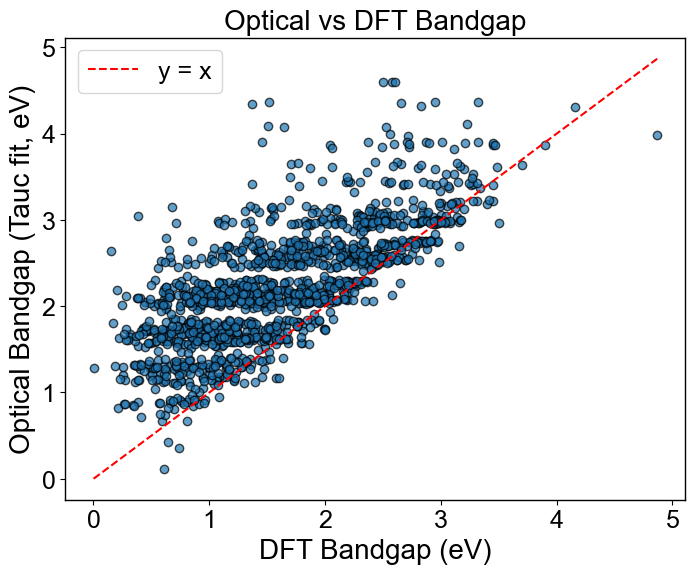

In [181]:
optical_Egs = []
alphas = []

for idx, row in df.iterrows():
    try:
        energy = np.array(row.omega)  # in eV
        Re_eps = np.array(row.rel_permittivity_real)
        Im_eps = np.array(row.rel_permittivity_imag)

        eps1 = np.mean(Re_eps[:, [0,1,2], [0,1,2]], axis=1)
        eps2 = np.mean(Im_eps[:, [0,1,2], [0,1,2]], axis=1)

        alpha = absorption_coef(energy, eps1, eps2)
        alphas.append(alpha)  # store alpha spectrum
        E_min, E_max = 0.2, 5
        mask = (energy >= E_min) & (energy <= E_max)
        energy_cut, alpha_cut = energy[mask], alpha[mask]
        Eg_input = row.bandgap_openmx  # provided (DFT or reference)

        Eg_list = suram_algorithm(energy_cut, alpha_cut, m=0.5,
                    normalize_tp=True,
                    k_segments=20,
                    merge_tol=0.05,
                    slope_jump=0.005,
                    dTP_min=0.001)

        optical_Egs.append(Eg_list)
    except Exception as e:
        print(f"Row {idx} failed: {e}")
        optical_Egs.append(np.nan)
        alphas.append(np.nan)

# Store results in df
df["optical_bandgap"] = optical_Egs
df["alpha"] = alphas  # each entry is a numpy array of α(ω)
from sklearn.metrics import r2_score

mask = df["optical_bandgap"].notna() & df["bandgap_openmx"].notna()
x = df.loc[mask, "bandgap_openmx"].values
y = df.loc[mask, "optical_bandgap"].values

# Scatter plot
plt.figure(figsize=(8,6))
plt.scatter(x, y, alpha=0.7, edgecolor="k")

# Add y=x reference line
print(f"R² = {r2_score(x, y):.3f}")
lims = [min(x.min(), y.min()), max(x.max(), y.max())]
plt.plot(lims,lims, "r--", label="y = x")
plt.xlabel("DFT Bandgap (eV)")
plt.ylabel("Optical Bandgap (Tauc fit, eV)")
plt.title(f"Optical vs DFT Bandgap")
plt.legend()
plt.show()


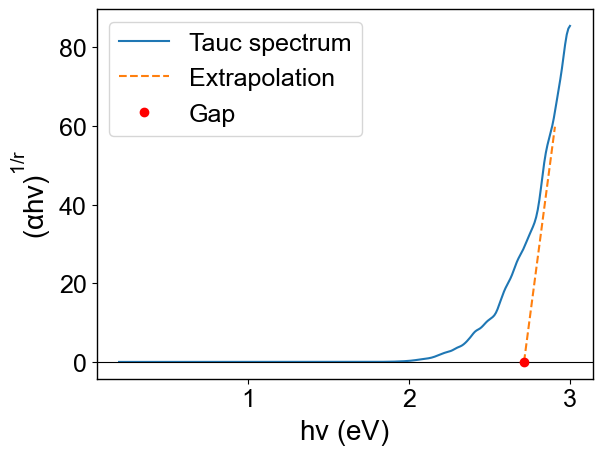

Provided Eg: 1.8316375473480755
Estimated Eg: 2.714729396947223


In [216]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.signal import savgol_filter

def tauc_fit(energy, absorption, r=2.0, imgfile=None, dpi=150, show=False):
    """
    Perform Tauc analysis on absorption data.

    Parameters
    ----------
    energy : array-like
        Photon energy in eV (x-axis).
    absorption : array-like
        Absorption coefficient (α) in cm^-1 (y-axis).
    r : float
        Tauc exponent (2 for direct allowed, 0.5 for indirect allowed, etc.).
    imgfile : str, optional
        If given, save a plot to this file (extension determines format).
    dpi : int
        Resolution of saved plot.
    show : bool
        Whether to display the plot interactively.

    Returns
    -------
    gap : float
        Estimated optical band gap in eV.
    """

    energy = np.asarray(energy, dtype=float)
    absorption = np.asarray(absorption, dtype=float)

    # Tauc transform
    tauc_y = (energy * absorption) ** (1.0 / r)

    # Smooth + interpolation
    y_interp = interp1d(energy, savgol_filter(tauc_y, 51, 3), fill_value="extrapolate")
    x = np.linspace(energy[0], energy[-1], 5000)

    # Derivatives
    dy = np.diff(y_interp(x), 1)
    dx = np.diff(x, 1)
    y_1d = interp1d(x[:-1], dy / dx, fill_value="extrapolate")

    d2y = np.diff(y_interp(x), 2)
    dx2 = x[1] - x[0]
    y_2d = interp1d(x[:-2], d2y / (dx2**2), fill_value="extrapolate")

    # Locate gap point
    gradmax = 0.0
    x_0, y_0 = None, None
    for i in range(2, len(x[:-2])):
        grad = y_1d(x[:-2])[i]
        if grad > gradmax:
            gradmax = grad
        if (np.allclose(y_2d(x[:-2])[i], 0.0, atol=1e-3)
            and y_interp(x)[i] > 0.1 * np.max(tauc_y)
            and grad >= gradmax):
            x_0 = x[i]
            y_0 = y_interp(x)[i]

    if x_0 is None:
        raise RuntimeError("No valid Tauc point found — check smoothing/window parameters.")

    # Linear extrapolation
    m = y_1d(x_0)
    c = y_0 - m * x_0
    gap = (0 - c) / m

    # Optional plot
    if imgfile or show:
        plt.figure()
        plt.xlabel(r'$h\nu$ (eV)')
        plt.ylabel(r'$(\alpha h \nu)^{1/r}$')
        # plt.figtext(0.15, 0.8, f'Optical Gap = {gap:.2f} eV')

        plt.plot(energy, tauc_y, '-', label="Tauc spectrum")
        plt.plot([gap, (0.7*np.max(tauc_y)-c)/m],
                 [0, 0.7*np.max(tauc_y)], '--', label="Extrapolation")
        plt.axhline(0, color="k", lw=0.8)
        plt.plot(gap, 0, 'ro', label="Gap")

        plt.legend()
        if imgfile:
            plt.savefig(imgfile, dpi=dpi)
            plt.close()
        if show:
            plt.show()

    return gap

row = df.sample(1).iloc[0]
energy = np.array(row.omega)
Re_eps = np.array(row.rel_permittivity_real)
Im_eps = np.array(row.rel_permittivity_imag)
eps1 = np.mean(Re_eps[:, [0,1,2], [0,1,2]], axis=1)
eps2 = np.mean(Im_eps[:, [0,1,2], [0,1,2]], axis=1)

alpha = absorption_coef(energy, eps1, eps2)

# Focus window
E_min, E_max = 0.2, 3
mask = (energy >= E_min) & (energy <= E_max)
energy_cut, alpha_cut = energy[mask], alpha[mask]

Eg_list = tauc_fit(energy_cut, alpha_cut, r=0.5, show=True)
print("Provided Eg:", row.bandgap_openmx)
print("Estimated Eg:", Eg_list)